# HAI + HAIEnd — Data Analysis

| Section | What it covers |
|---------|----------------|
| **1. HAI alone** | Subsystems, column types, what actually varies |
| **2. HAIEnd alone** | Control signals, PLC outputs, what actually varies |
| **3. The 1-second offset** | Cause → effect relationship between the two datasets |
| **4. File timeline** | Chronological order, gaps — data is NOT continuous |
| **5. Merge** | Combine HAI + HAIEnd, handle duplicates |
| **6. Column audit** | Variable vs constant after merge — real feature count |
| **7. EDA** | Distributions, correlations, attack timeline |

In [1]:
import os
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

HAI_DIR   = 'C:/Users/ahmma/Desktop/farah/hai-23.05'
HIEND_DIR = 'C:/Users/ahmma/Desktop/farah/haiend-23.05'

META_COLS = {'timestamp', 'attack', 'label', 'attack_p1', 'attack_p2', 'attack_p3'}

def classify_sensor(series):
    """Classify a sensor column as binary, stepped, or continuous."""
    unique_vals = series.dropna().unique()
    n_unique = len(unique_vals)
    if n_unique <= 2:
        return 'binary'
    if n_unique <= 20:
        return 'stepped'
    return 'continuous'

---
## Section 1 — HAI Dataset Alone

| Prefix | Subsystem | Description |
|--------|-----------|-------------|
| `P1_` | Boiler  | Flow, pressure, temperature, level |
| `P2_` | Turbine | Thermal process signals |
| `P3_` | Water treatment | Limit and alarm signals |
| `P4_` | Gate valve | Valve position and control |
| `x1001/2/3_` | Setpoint outputs | Computed setpoint values from controllers |

All 4 train files combined for column analysis. Train1 only for time series.

In [2]:
hai_parts = []
for i in range(1, 5):
    df = pd.read_csv(os.path.join(HAI_DIR, f'hai-train{i}.csv'))
    df.rename(columns={df.columns[0]: 'timestamp'}, inplace=True)
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df['_file'] = f'train{i}'
    hai_parts.append(df)
    print(f"  train{i}: {len(df):>7,} rows  |  {df.timestamp.iloc[0]}  ->  {df.timestamp.iloc[-1]}")

hai_all = pd.concat(hai_parts, ignore_index=True)
sensor_cols_hai = [c for c in hai_all.columns if c not in META_COLS and c != '_file']
print(f"\nCombined: {len(hai_all):,} rows  |  {len(sensor_cols_hai)} sensor columns")

prefix_map = {
    'P1_': 'P1 — Boiler',
    'P2_': 'P2 — Turbine',
    'P3_': 'P3 — Water treatment',
    'P4_': 'P4 — Gate valve',
    'x'  : 'x1001/2/3 — Setpoints',
}
counts = Counter()
for col in sensor_cols_hai:
    for pfx, label in prefix_map.items():
        if col.startswith(pfx):
            counts[label] += 1
            break
print()
for label, n in sorted(counts.items()):
    print(f"  {label:<35s} {n:>3}")

  train1: 280,800 rows  |  2022-08-04 18:00:01  ->  2022-08-08 00:00:00
  train2: 291,600 rows  |  2022-08-13 07:00:01  ->  2022-08-16 16:00:00
  train3: 126,000 rows  |  2022-08-19 16:00:01  ->  2022-08-21 03:00:00
  train4: 198,000 rows  |  2022-08-22 17:00:01  ->  2022-08-25 00:00:00

Combined: 896,400 rows  |  86 sensor columns

  P1 — Water treatment                 37
  P2 — Boiler/turbine                  24
  P3 — Auxiliary                        7
  P4 — Gate valve                      11
  x1001/2/3 — Setpoints                 7


In [3]:
arr_hai  = hai_all[sensor_cols_hai].values.astype(float)
stds_hai = arr_hai.std(axis=0)

const_hai    = [col for col, s in zip(sensor_cols_hai, stds_hai) if s < 1e-6]
variable_hai = [col for col, s in zip(sensor_cols_hai, stds_hai) if s >= 1e-6]

print(f"Total HAI sensor columns:  {len(sensor_cols_hai)}")
print(f"  Constant  (std < 1e-6):  {len(const_hai)}")
print(f"  Variable  (std >= 1e-6): {len(variable_hai)}")
print()
print("Constant columns:")
for c in const_hai:
    print(f"  {c:<30s}  fixed = {hai_all[c].iloc[0]}")

Total HAI sensor columns:  86
  Constant  (std < 1e-6):  20
  Variable  (std >= 1e-6): 66

Constant columns:
  P1_PIT01_HH                     fixed = 524320
  P1_PP01AD                       fixed = 0
  P1_PP01AR                       fixed = 0
  P1_PP01BD                       fixed = 1
  P1_PP01BR                       fixed = 1
  P1_PP02D                        fixed = 1
  P1_PP02R                        fixed = 1
  P1_SOL01D                       fixed = 524320
  P1_SOL03D                       fixed = 524320
  P1_STSP                         fixed = 1
  P2_Emerg                        fixed = 0
  P2_OnOff                        fixed = 1
  P2_RTR                          fixed = 2880
  P2_TripEx                       fixed = 1
  P2_VTR01                        fixed = 50
  P2_VTR02                        fixed = 50
  P2_VTR03                        fixed = 50
  P2_VTR04                        fixed = 50
  P3_LH01                         fixed = 70
  P3_LL01                       

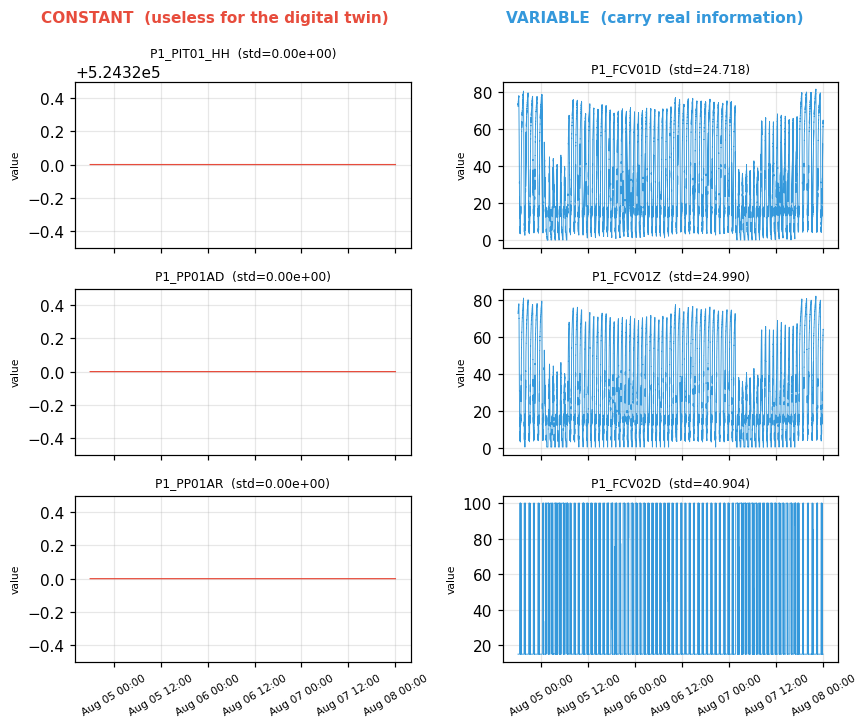

In [4]:
# --- Constant vs Variable: side-by-side visual proof ---
# Left column: constant sensors (flat lines)
# Right column: variable sensors (real signals)
# Using train1 so it's a single continuous time window

hai_t1     = hai_parts[0]
n_show     = 3  # Exactly 3 rows × 2 columns = 6 plots
show_const = const_hai[:n_show]
show_var   = variable_hai[:n_show]

fig, axes = plt.subplots(3, 2, figsize=(8, 6.6), sharex=True)

for row in range(3):
    # left: constant
    ax_c = axes[row, 0]
    col_c = show_const[row]
    ax_c.plot(hai_t1['timestamp'], hai_t1[col_c], color='#e74c3c', linewidth=0.8)
    ax_c.set_title(f'{col_c}  (std={stds_hai[sensor_cols_hai.index(col_c)]:.2e})', fontsize=8)
    ax_c.set_ylabel('value', fontsize=7)
    ax_c.grid(alpha=0.3)
    # fix y-axis so flat line is visible, not hidden at edge
    val = hai_t1[col_c].iloc[0]
    ax_c.set_ylim(val - 0.5, val + 0.5)

    # right: variable
    ax_v = axes[row, 1]
    col_v = show_var[row]
    ax_v.plot(hai_t1['timestamp'], hai_t1[col_v], color='#3498db', linewidth=0.6)
    ax_v.set_title(f'{col_v}  (std={stds_hai[sensor_cols_hai.index(col_v)]:.3f})', fontsize=8)
    ax_v.set_ylabel('value', fontsize=7)
    ax_v.grid(alpha=0.3)

for col_ax in [axes[-1, 0], axes[-1, 1]]:
    col_ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d %H:%M'))
    plt.setp(col_ax.xaxis.get_majorticklabels(), rotation=30, fontsize=7)

fig.text(0.25, 0.98, 'CONSTANT  (useless for the digital twin)',
         ha='center', color='#e74c3c', fontsize=10, fontweight='bold')
fig.text(0.75, 0.98, 'VARIABLE  (carry real information)',
         ha='center', color='#3498db', fontsize=10, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

Sensor types across variable HAI columns:
  binary         6   e.g. ['P1_PP04D', 'P2_ATSW_Lamp', 'P2_AutoGO']
  stepped        1   e.g. ['P2_ManualSD']
  continuous    59   e.g. ['P1_FCV01D', 'P1_FCV01Z', 'P1_FCV02D']

Breakdown per subsystem:
type       binary  continuous  stepped
subsystem                             
P1              1          26        0
P2              5          10        1
P3              0           5        0
P4              0          11        0
x1001/2/3       0           7        0


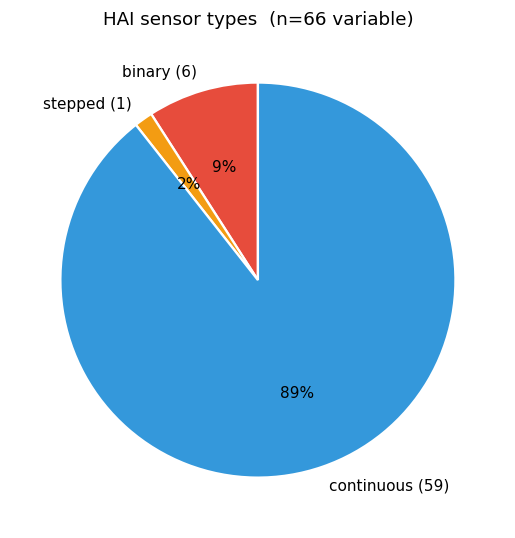

In [5]:
types_hai   = {col: classify_sensor(hai_all[col]) for col in variable_hai}
type_counts = Counter(types_hai.values())

print("Sensor types across variable HAI columns:")
for t in ['binary', 'stepped', 'continuous']:
    cols = [c for c, v in types_hai.items() if v == t]
    print(f"  {t:<12s} {type_counts[t]:>3}   e.g. {cols[:3]}")

print("\nBreakdown per subsystem:")
rows = []
for col, typ in types_hai.items():
    for pfx, label in prefix_map.items():
        if col.startswith(pfx):
            rows.append({'subsystem': label.split('—')[0].strip(), 'type': typ})
            break
breakdown = pd.DataFrame(rows).groupby(['subsystem','type']).size().unstack(fill_value=0)
print(breakdown)

colors = {'binary': '#e74c3c', 'stepped': '#f39c12', 'continuous': '#3498db'}
fig, ax = plt.subplots(figsize=(5, 5))
labels = [f"{t} ({type_counts[t]})" for t in ['binary','stepped','continuous']]
sizes  = [type_counts[t] for t in ['binary','stepped','continuous']]
clrs   = [colors[t]      for t in ['binary','stepped','continuous']]
ax.pie(sizes, labels=labels, colors=clrs, autopct='%1.0f%%', startangle=90,
       wedgeprops={'edgecolor':'white','linewidth':1.5})
ax.set_title(f'HAI sensor types  (n={len(variable_hai)} variable)')
plt.tight_layout()
plt.show()

---
## Section 2 — HAIEnd Dataset Alone

HAIEnd records the **control layer** — what the PLC commands the system to do.

| Prefix | Type | Description |
|--------|------|-------------|
| `DM-` | Data Module signals | Direct counterparts to HAI P1 sensors (valves, flow, pressure) |
| `1001.x-OUT` … `1020.x-OUT` | PLC function block outputs | Controller outputs — most are inactive |
| `GATEOPEN`, `PP04` | Discrete control | Gate open command, pump control |

Key expectation: most of the 225 columns will be constant (inactive PLC blocks).

In [6]:
end_parts = []
for i in range(1, 5):
    df = pd.read_csv(os.path.join(HIEND_DIR, f'end-train{i}.csv'))
    df.rename(columns={df.columns[0]: 'timestamp'}, inplace=True)
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df['_file'] = f'train{i}'
    end_parts.append(df)
    print(f"  train{i}: {len(df):>7,} rows  |  {df.timestamp.iloc[0]}  ->  {df.timestamp.iloc[-1]}")

end_all = pd.concat(end_parts, ignore_index=True)
sensor_cols_end = [c for c in end_all.columns if c not in META_COLS and c != '_file']
print(f"\nCombined: {len(end_all):,} rows  |  {len(sensor_cols_end)} sensor columns")

prefix_map_end = {
    'DM-'   : 'DM — Data Module',
    '1001.' : '1001.x — PLC block',
    '1002.' : '1002.x — PLC block',
    '1003.' : '1003.x — PLC block',
    '1004.' : '1004.x — PLC block',
    '1010.' : '1010.x — PLC block',
    '1011.' : '1011.x — PLC block',
    '1020.' : '1020.x — PLC block',
}
counts_end = Counter()
for col in sensor_cols_end:
    for pfx, label in prefix_map_end.items():
        if col.startswith(pfx):
            counts_end[label] += 1
            break
    else:
        counts_end['Other'] += 1

print()
for label, n in sorted(counts_end.items(), key=lambda x: -x[1]):
    print(f"  {label:<35s} {n:>3}")

  train1: 280,800 rows  |  2022-08-04 18:00:00  ->  2022-08-07 23:59:59
  train2: 291,600 rows  |  2022-08-13 07:00:00  ->  2022-08-16 15:59:59
  train3: 126,000 rows  |  2022-08-19 16:00:00  ->  2022-08-21 02:59:59
  train4: 198,000 rows  |  2022-08-22 17:00:00  ->  2022-08-24 23:59:59

Combined: 896,400 rows  |  225 sensor columns

  DM — Data Module                     71
  1010.x — PLC block                   32
  1011.x — PLC block                   32
  1004.x — PLC block                   25
  1002.x — PLC block                   19
  1003.x — PLC block                   16
  1020.x — PLC block                   14
  1001.x — PLC block                   12
  Other                                 4


In [7]:
arr_end  = end_all[sensor_cols_end].values.astype(float)
stds_end = arr_end.std(axis=0)

const_end    = [col for col, s in zip(sensor_cols_end, stds_end) if s < 1e-6]
variable_end = [col for col, s in zip(sensor_cols_end, stds_end) if s >= 1e-6]

print(f"Total HAIEnd sensor columns: {len(sensor_cols_end)}")
print(f"  Constant  (std < 1e-6):    {len(const_end)}  — inactive PLC blocks")
print(f"  Variable  (std >= 1e-6):   {len(variable_end)}  — useful features")
print()

const_groups = Counter()
for col in const_end:
    for pfx in prefix_map_end:
        if col.startswith(pfx):
            const_groups[pfx] += 1
            break
    else:
        const_groups['Other'] += 1

print("Constant columns by group:")
for pfx, n in sorted(const_groups.items(), key=lambda x: -x[1]):
    print(f"  {pfx:<15s} {n:>3} constant")
print()
print("Variable HAIEnd columns:")
for col in variable_end:
    print(f"  {col}")

Total HAIEnd sensor columns: 225
  Constant  (std < 1e-6):    158  — inactive PLC blocks
  Variable  (std >= 1e-6):   67  — useful features

Constant columns by group:
  DM-              39 constant
  1010.            32 constant
  1011.            32 constant
  1004.            23 constant
  1002.            12 constant
  1020.             8 constant
  1001.             5 constant
  1003.             5 constant
  Other             2 constant

Variable HAIEnd columns:
  DM-FT01Z
  DM-FT02Z
  DM-FT03Z
  1004.21-OUT
  1004.24-OUT
  1020.18-OUT
  1020.20-OUT
  1020.21-OUT
  DM-PP04-D
  1001.5-OUT
  1001.13-OUT
  1001.14-OUT
  1001.15-OUT
  1001.16-OUT
  1001.17-OUT
  1001.20-OUT
  1002.7-OUT
  1002.8-OUT
  1002.9-OUT
  1002.20-OUT
  1002.21-OUT
  1002.30-OUT
  1002.31-OUT
  1003.5-OUT
  1003.10-OUT
  1003.11-OUT
  1003.17-OUT
  1003.18-OUT
  1003.23-OUT
  1003.24-OUT
  1003.25-OUT
  1003.26-OUT
  1003.29-OUT
  1003.30-OUT
  1020.13-OUT
  1020.14-OUT
  1020.15-OUT
  DM-AIT-DO
  DM-AIT-PH
 

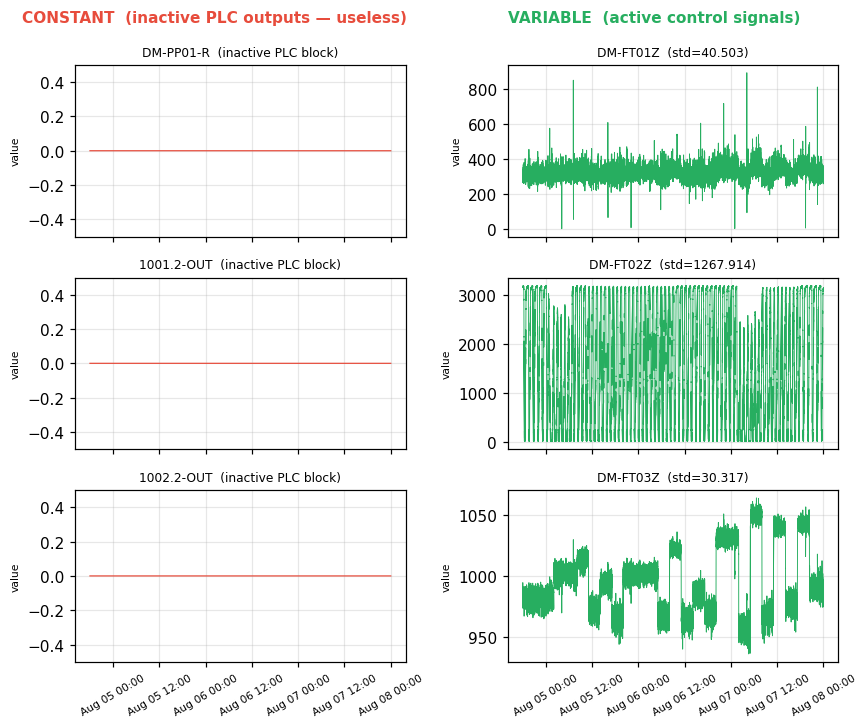

In [8]:
# --- Constant vs Variable: side-by-side visual proof for HAIEnd ---
end_t1  = end_parts[0]

# pick a spread of constant columns from different PLC block groups
groups_seen = set()
show_const_end = []
for col in const_end:
    grp = next((pfx for pfx in prefix_map_end if col.startswith(pfx)), 'Other')
    if grp not in groups_seen:
        show_const_end.append(col)
        groups_seen.add(grp)
    if len(show_const_end) == 3:  # Only 3 constant signals (left column)
        break

show_var_end = variable_end[:3]  # Only 3 variable signals (right column)

fig, axes = plt.subplots(3, 2, figsize=(8, 6.6), sharex=True)  # 3 rows × 2 columns

for row in range(3):
    # left: constant
    ax_c  = axes[row, 0]
    col_c = show_const_end[row]
    ax_c.plot(end_t1['timestamp'], end_t1[col_c], color='#e74c3c', linewidth=0.8)
    ax_c.set_title(f'{col_c}  (inactive PLC block)', fontsize=8)
    ax_c.set_ylabel('value', fontsize=7)
    ax_c.grid(alpha=0.3)
    val = end_t1[col_c].iloc[0]
    ax_c.set_ylim(val - 0.5, val + 0.5)

    # right: variable
    ax_v  = axes[row, 1]
    col_v = show_var_end[row]
    ax_v.plot(end_t1['timestamp'], end_t1[col_v], color='#27ae60', linewidth=0.6)
    ax_v.set_title(f'{col_v}  (std={stds_end[sensor_cols_end.index(col_v)]:.3f})', fontsize=8)
    ax_v.set_ylabel('value', fontsize=7)
    ax_v.grid(alpha=0.3)

for col_ax in [axes[-1, 0], axes[-1, 1]]:
    col_ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d %H:%M'))
    plt.setp(col_ax.xaxis.get_majorticklabels(), rotation=30, fontsize=7)

fig.text(0.25, 0.98, 'CONSTANT  (inactive PLC outputs — useless)',
         ha='center', color='#e74c3c', fontsize=10, fontweight='bold')
fig.text(0.75, 0.98, 'VARIABLE  (active control signals)',
         ha='center', color='#27ae60', fontsize=10, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

Sensor types across variable HAIEnd columns:
  binary         7   ['1004.21-OUT', '1004.24-OUT', '1020.18-OUT', '1020.20-OUT', '1020.21-OUT']
  stepped        1   ['DM-AIT-DO']
  continuous    59   ['DM-FT01Z', 'DM-FT02Z', 'DM-FT03Z', '1001.5-OUT', '1001.13-OUT']


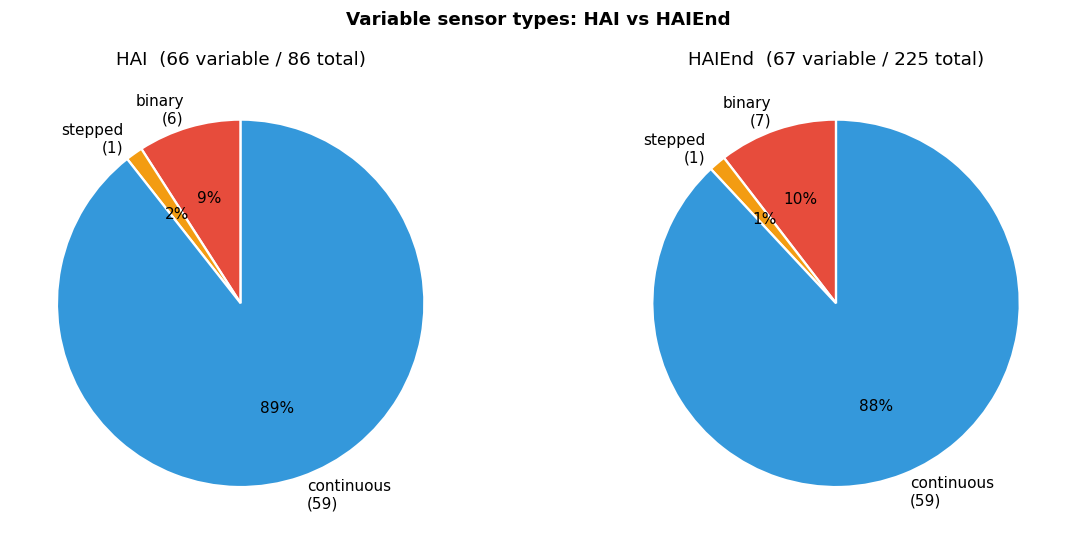

In [9]:
types_end       = {col: classify_sensor(end_all[col]) for col in variable_end}
type_counts_end = Counter(types_end.values())

print("Sensor types across variable HAIEnd columns:")
for t in ['binary', 'stepped', 'continuous']:
    cols = [c for c, v in types_end.items() if v == t]
    print(f"  {t:<12s} {type_counts_end.get(t,0):>3}   {cols[:5]}")

colors = {'binary': '#e74c3c', 'stepped': '#f39c12', 'continuous': '#3498db'}
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

for ax, (title, tc) in zip(axes, [
    (f'HAI  ({len(variable_hai)} variable / {len(sensor_cols_hai)} total)', type_counts),
    (f'HAIEnd  ({len(variable_end)} variable / {len(sensor_cols_end)} total)', type_counts_end),
]):
    sizes  = [tc.get(t, 0) for t in ['binary','stepped','continuous']]
    labels = [f"{t}\n({tc.get(t,0)})" for t in ['binary','stepped','continuous']]
    clrs   = [colors[t] for t in ['binary','stepped','continuous']]
    ax.pie(sizes, labels=labels, colors=clrs, autopct='%1.0f%%', startangle=90,
           wedgeprops={'edgecolor':'white','linewidth':1.5})
    ax.set_title(title)

fig.suptitle('Variable sensor types: HAI vs HAIEnd', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Section 3 — Are "constant" columns really constant? Check test data too

Some columns were constant across all 4 train files. But train data is normal operation only.  
Test files contain **attack periods** — do any of those "constant" columns suddenly change?

- Still constant in test → truly useless, safe to ignore  
- Varies in test → was dormant during normal operation, activates under attack/abnormal conditions → **interesting**

In [10]:
# Load HAI + HAIEnd test files
hai_test_parts, end_test_parts = [], []
for i in range(1, 3):
    df = pd.read_csv(os.path.join(HAI_DIR, f'hai-test{i}.csv'))
    df.rename(columns={df.columns[0]: 'timestamp'}, inplace=True)
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df['_file'] = f'test{i}'
    hai_test_parts.append(df)

    df = pd.read_csv(os.path.join(HIEND_DIR, f'end-test{i}.csv'))
    df.rename(columns={df.columns[0]: 'timestamp'}, inplace=True)
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df['_file'] = f'test{i}'
    end_test_parts.append(df)

hai_test = pd.concat(hai_test_parts, ignore_index=True)
end_test = pd.concat(end_test_parts, ignore_index=True)

print(f"HAI test:    {len(hai_test):,} rows  |  {hai_test.timestamp.iloc[0]}  ->  {hai_test.timestamp.iloc[-1]}")
print(f"HAIEnd test: {len(end_test):,} rows  |  {end_test.timestamp.iloc[0]}  ->  {end_test.timestamp.iloc[-1]}")
if 'attack' in hai_test.columns:
    n_atk = (hai_test['attack'] > 0).sum()
    print(f"Attack rows in HAI test: {n_atk:,} / {len(hai_test):,}  ({100*n_atk/len(hai_test):.1f}%)")

HAI test:    284,400 rows  |  2022-08-12 16:00:01  ->  2022-08-19 16:00:00
HAIEnd test: 284,400 rows  |  2022-08-12 16:00:00  ->  2022-08-19 15:59:59


In [11]:
# Check: are the constant-in-train columns still constant in test?
def check_const_in_test(const_cols, test_df, dataset_name):
    rows = []
    for col in const_cols:
        if col not in test_df.columns:
            continue
        std_test  = float(test_df[col].std())
        n_unique  = int(test_df[col].nunique())
        rows.append({'column': col, 'std_test': round(std_test, 6),
                     'n_unique_test': n_unique, 'still_constant': std_test < 1e-6})
    df = pd.DataFrame(rows)
    wakes_up = df[~df['still_constant']]
    print(f"{'='*55}")
    print(f"{dataset_name}")
    print(f"  Constant in train:       {len(const_cols)}")
    print(f"  Still constant in test:  {df['still_constant'].sum()}")
    print(f"  ACTIVATES in test:       {len(wakes_up)}  ← interesting!")
    if len(wakes_up):
        print()
        print(wakes_up[['column', 'std_test', 'n_unique_test']].to_string(index=False))
    return wakes_up

hai_wakes = check_const_in_test(const_hai, hai_test, 'HAI')
print()
end_wakes = check_const_in_test(const_end, end_test, 'HAIEnd')

HAI
  Constant in train:       20
  Still constant in test:  18
  ACTIVATES in test:       2  ← interesting!

  column  std_test  n_unique_test
P2_Emerg  0.018177              2
P2_OnOff  0.020105              2

HAIEnd
  Constant in train:       158
  Still constant in test:  151
  ACTIVATES in test:       7  ← interesting!

        column  std_test  n_unique_test
     DM-LSH-03  0.024007              2
  DQ03-LCV01-D  0.046225              2
DQ04-LCV01-DEV  0.042267              2
    1001.9-OUT  0.760577              2
   1002.14-OUT  0.643714              2
  DM-LCV01-MIS  0.042267              2
  DM-PCV01-DEV  0.026838              2


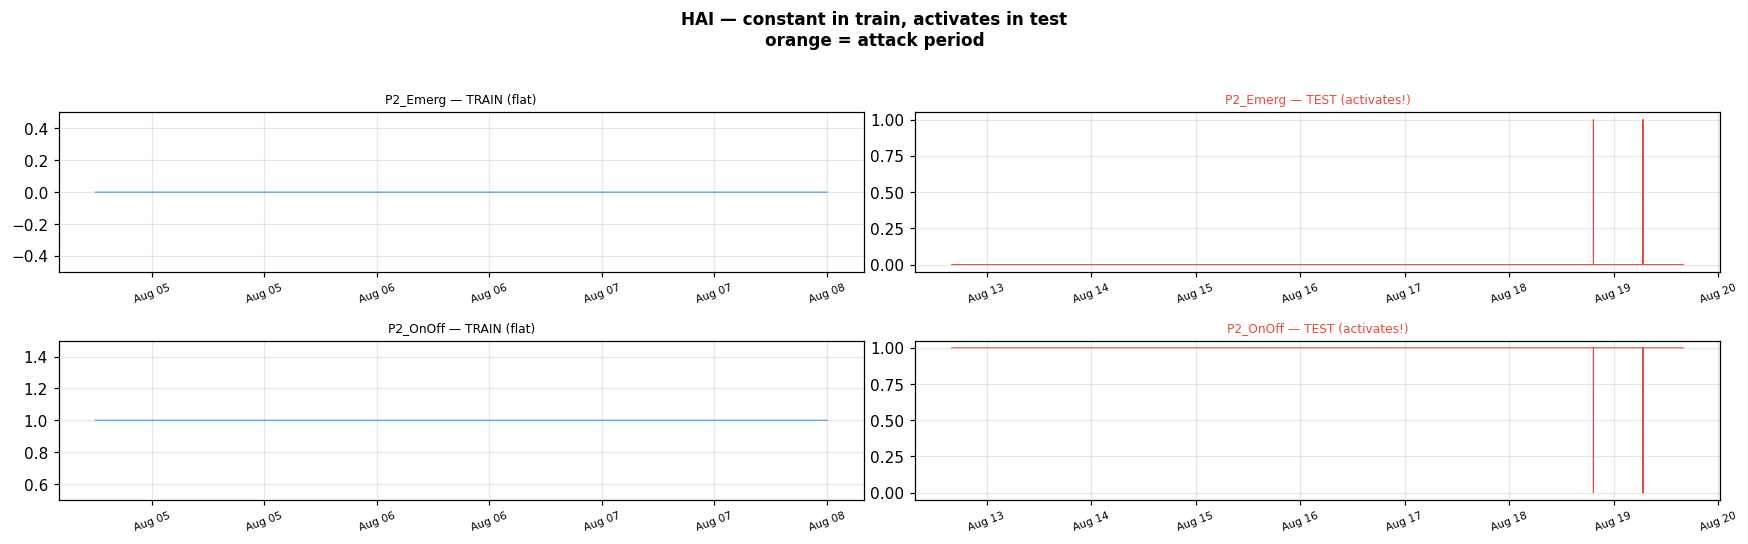

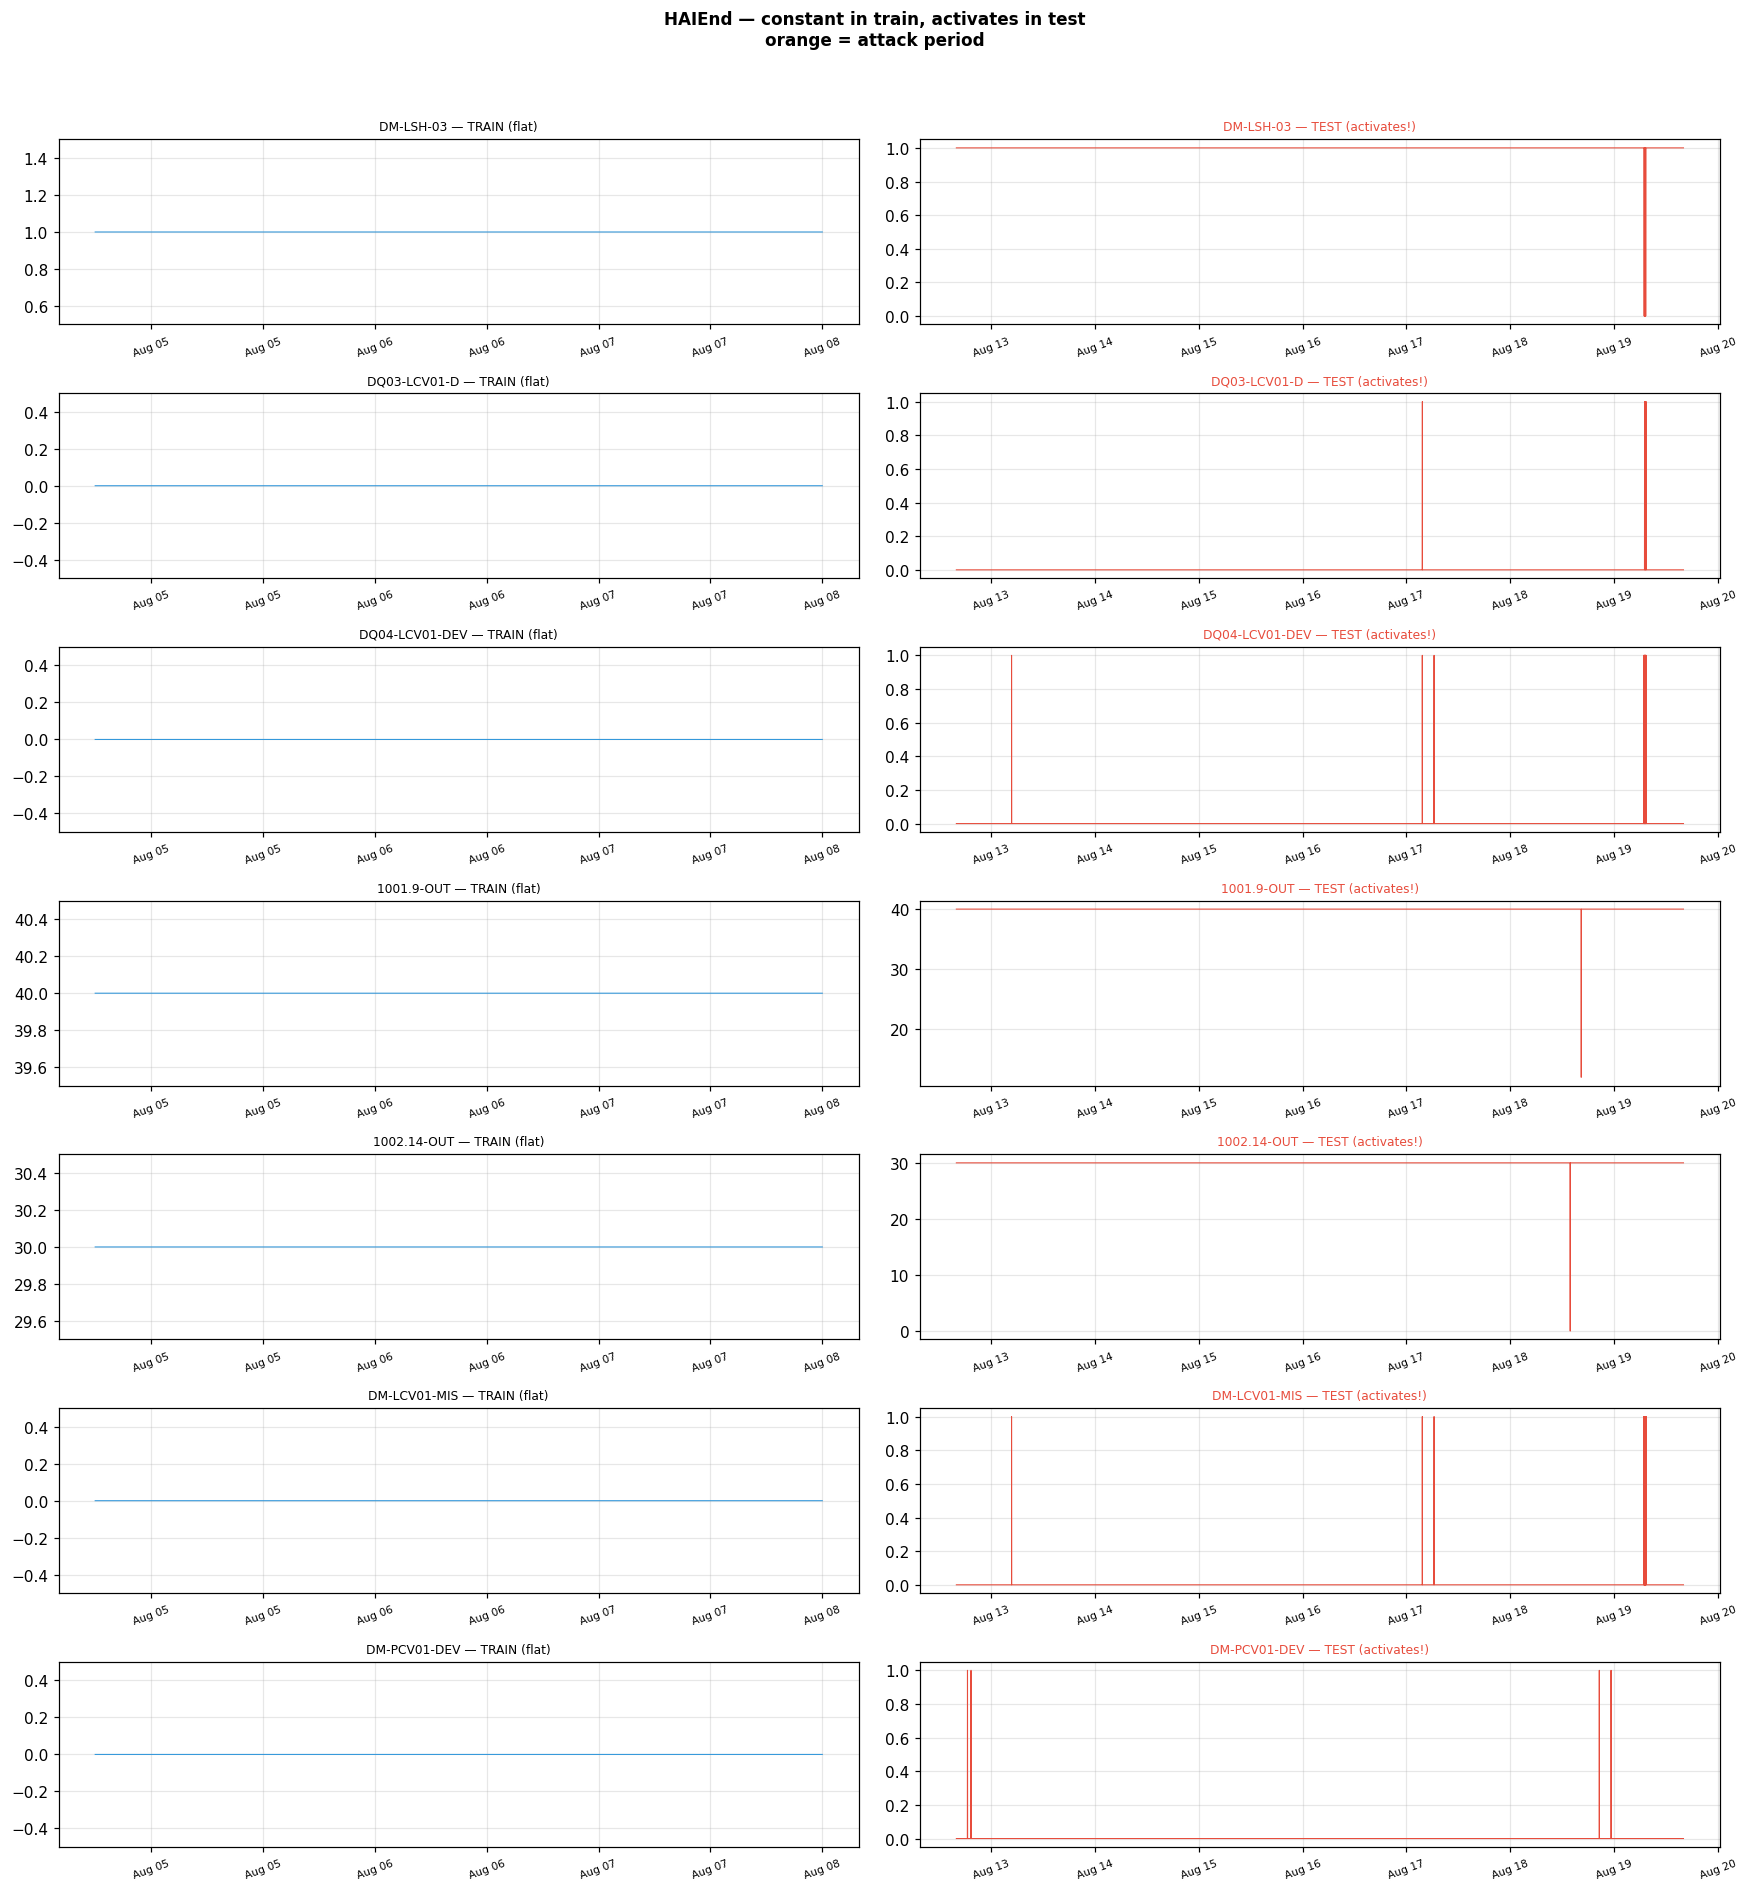

In [12]:
# Plot wake-up columns: flat in train (left), active in test (right) with attack shading
def plot_wakeup_cols(wakes_df, train_parts, test_parts, dataset_name, attack_col='attack'):
    cols = wakes_df['column'].tolist()
    if not cols:
        print(f"No wake-up columns in {dataset_name} — all stay constant in test.")
        return
    train_t1 = train_parts[0]
    test_all  = pd.concat(test_parts, ignore_index=True)
    n = len(cols)
    fig, axes = plt.subplots(n, 2, figsize=(16, 2.5 * n), squeeze=False)
    fig.suptitle(f'{dataset_name} — constant in train, activates in test\norange = attack period',
                 fontsize=11, fontweight='bold')
    for row, col in enumerate(cols):
        # left: train — flat
        ax_tr = axes[row, 0]
        ax_tr.plot(train_t1['timestamp'], train_t1[col], color='#3498db', linewidth=0.7)
        val = train_t1[col].iloc[0]
        ax_tr.set_ylim(val - 0.5, val + 0.5)
        ax_tr.set_title(f'{col} — TRAIN (flat)', fontsize=8)
        ax_tr.grid(alpha=0.3)
        ax_tr.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
        plt.setp(ax_tr.xaxis.get_majorticklabels(), rotation=20, fontsize=7)
        # right: test — active
        ax_te = axes[row, 1]
        ax_te.plot(test_all['timestamp'], test_all[col], color='#e74c3c', linewidth=0.7)
        if attack_col in test_all.columns:
            atk  = test_all[attack_col].fillna(0).astype(float)
            ymin = test_all[col].min(); ymax = test_all[col].max()
            ax_te.fill_between(test_all['timestamp'], ymin, ymax,
                               where=atk > 0, alpha=0.2, color='orange', label='attack')
            ax_te.legend(fontsize=7)
        ax_te.set_title(f'{col} — TEST (activates!)', fontsize=8, color='#e74c3c')
        ax_te.grid(alpha=0.3)
        ax_te.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
        plt.setp(ax_te.xaxis.get_majorticklabels(), rotation=20, fontsize=7)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

plot_wakeup_cols(hai_wakes, hai_parts, hai_test_parts, 'HAI')
plot_wakeup_cols(end_wakes, end_parts, end_test_parts, 'HAIEnd')

### Section 3 — Summary

| Dataset | Total columns | Always constant (drop) | Wakes up in test | Variable in train (keep) |
|---------|:---:|:---:|:---:|:---:|
| HAI | 86 | 18 | 2 | 66 |
| HAIEnd | 225 | 151 | 7 | 67 |

- **Always constant** → drop from model input entirely  
- **Wakes up in test** → flat during training (model can't learn them), but active during attacks — keep in test evaluation to observe reconstruction error  
- **Variable in train** → these are the real features for the digital twin

---
## Section 4 — Duplicate Verification: HAI vs HAIEnd

The `data_loader.py` lists 35 HAI columns that are claimed to be duplicates of HAIEnd columns.  
Before trusting this list we need to verify three things:

1. Does the HAI column actually exist?
2. Does the HAIEnd counterpart actually exist?
3. Do the values actually match (correlation ≈ 1.0 after the 1s offset)?

In [13]:
# The claimed duplicate pairs from data_loader.py: (HAI_col, HAIEnd_col)
CLAIMED_PAIRS = [
    ('x1001_15_ASSIGN_OUT',    '1001.15-OUT'),   # NOTE: P1_B2016 may not exist
    ('P1_FCV01D',   'DM-FCV01-D'),
    ('P1_FCV01Z',   'DM-FCV01-Z'),
    ('P1_FCV02D',   'DM-FCV02-D'),
    ('P1_FCV02Z',   'DM-FCV02-Z'),
    ('P1_FCV03D',   'DM-FCV03-D'),
    ('P1_FCV03Z',   'DM-FCV03-Z'),
    ('P1_FT01',     'DM-FT01'),
    ('P1_FT01Z',    'DM-FT01Z'),
    ('P1_FT02',     'DM-FT02'),
    ('P1_FT02Z',    'DM-FT02Z'),
    ('P1_FT03',     'DM-FT03'),
    ('P1_FT03Z',    'DM-FT03Z'),
    ('P1_LCV01D',   'DM-LCV01-D'),
    ('P1_LCV01Z',   'DM-LCV01-Z'),
    ('P1_LIT01',    'DM-LIT01'),
    ('P1_PCV01D',   'DM-PCV01-D'),
    ('P1_PCV01Z',   'DM-PCV01-Z'),
    ('P1_PCV02D',   'DM-PCV02-D'),
    ('P1_PCV02Z',   'DM-PCV02-Z'),
    ('P1_PIT01_HH', 'DM-PIT01-HH'),
    ('P1_PIT01',    'DM-PIT01'),
    ('P1_PIT02',    'DM-PIT02'),
    ('P1_PP01AD',   'DM-PP01A-D'),
    ('P1_PP01AR',   'DM-PP01A-R'),
    ('P1_PP01BD',   'DM-PP01B-D'),
    ('P1_PP01BR',   'DM-PP01B-R'),
    ('P1_PP02D',    'DM-PP02-D'),
    ('P1_PP02R',    'DM-PP02-R'),
    ('P1_SOL01D',   'DM-SOL01-D'),
    ('P1_SOL03D',   'DM-SOL03-D'),
    ('P1_STSP',     'DM-ST-SP'),
    ('P1_TIT01',    'DM-TIT01'),
    ('P1_TIT03',    'DM-TIT02'),   # naming mismatch: HAI TIT03 = HAIEnd TIT02
    ('P4_ST_GOV',   'GATEOPEN'),
]

# Step 1 & 2 — existence check
hai1 = hai_parts[0]   # already loaded
end1 = end_parts[0]

results = []
for hai_col, end_col in CLAIMED_PAIRS:
    hai_exists = hai_col in hai1.columns
    end_exists = end_col in end1.columns
    results.append({
        'HAI_col'    : hai_col,
        'HAIEnd_col' : end_col,
        'HAI_exists' : hai_exists,
        'END_exists' : end_exists,
    })

df_check = pd.DataFrame(results)
missing_hai = df_check[~df_check['HAI_exists']]
missing_end = df_check[~df_check['END_exists']]

print(f"Total claimed pairs: {len(CLAIMED_PAIRS)}")
print(f"HAI col missing:     {len(missing_hai)}")
print(f"HAIEnd col missing:  {len(missing_end)}")
print()
if len(missing_hai):
    print("HAI columns NOT found:")
    for _, r in missing_hai.iterrows():
        print(f"  '{r.HAI_col}'  (claimed counterpart: {r.HAIEnd_col})")
if len(missing_end):
    print("HAIEnd columns NOT found:")
    for _, r in missing_end.iterrows():
        print(f"  '{r.HAIEnd_col}'  (claimed source: {r.HAI_col})")

Total claimed pairs: 35
HAI col missing:     0
HAIEnd col missing:  0



In [14]:
# Step 3 — correlation check for valid pairs (both columns exist)
# HAIEnd leads HAI by 1s, so shift HAIEnd back by 1 row before comparing

valid_pairs = [(h, e) for h, e in CLAIMED_PAIRS
               if h in hai1.columns and e in end1.columns]

merged_dup = pd.merge(
    hai1[['timestamp'] + [h for h, _ in valid_pairs]],
    end1[['timestamp'] + [e for _, e in valid_pairs]],
    on='timestamp', how='inner'
)

corr_results = []
for hai_col, end_col in valid_pairs:
    a = merged_dup[hai_col].values[1:]    # HAI at t
    b = merged_dup[end_col].values[:-1]   # HAIEnd at t-1 = same physical moment

    if a.std() < 1e-9 and b.std() < 1e-9:
        verdict, corr = 'both constant', 1.0
    elif a.std() < 1e-9 or b.std() < 1e-9:
        verdict, corr = 'one constant', float(np.nan)
    else:
        corr = float(np.corrcoef(a, b)[0, 1])
        verdict = 'DUPLICATE ✓' if corr > 0.99 else ('close' if corr > 0.9 else 'DIFFERENT ✗')

    corr_results.append({'HAI': hai_col, 'HAIEnd': end_col,
                         'corr': round(corr, 4) if not np.isnan(corr) else None,
                         'verdict': verdict})

df_corr = pd.DataFrame(corr_results)
print(df_corr.to_string(index=False))
print()
print(f"DUPLICATE ✓  (corr > 0.99): {(df_corr.verdict == 'DUPLICATE ✓').sum()}")
print(f"both constant:              {(df_corr.verdict == 'both constant').sum()}")
print(f"one constant:               {(df_corr.verdict == 'one constant').sum()}")
print(f"close (0.9–0.99):           {(df_corr.verdict == 'close').sum()}")
print(f"DIFFERENT ✗  (corr < 0.9):  {(df_corr.verdict == 'DIFFERENT ✗').sum()}")

                HAI      HAIEnd   corr       verdict
x1001_15_ASSIGN_OUT 1001.15-OUT 0.9992   DUPLICATE ✓
          P1_FCV01D  DM-FCV01-D 0.9998   DUPLICATE ✓
          P1_FCV01Z  DM-FCV01-Z 0.9998   DUPLICATE ✓
          P1_FCV02D  DM-FCV02-D 0.9701         close
          P1_FCV02Z  DM-FCV02-Z 0.9999   DUPLICATE ✓
          P1_FCV03D  DM-FCV03-D 0.9998   DUPLICATE ✓
          P1_FCV03Z  DM-FCV03-Z 0.9994   DUPLICATE ✓
            P1_FT01     DM-FT01 0.9950   DUPLICATE ✓
           P1_FT01Z    DM-FT01Z 0.9939   DUPLICATE ✓
            P1_FT02     DM-FT02 0.9998   DUPLICATE ✓
           P1_FT02Z    DM-FT02Z 0.9997   DUPLICATE ✓
            P1_FT03     DM-FT03 0.9991   DUPLICATE ✓
           P1_FT03Z    DM-FT03Z 0.9988   DUPLICATE ✓
          P1_LCV01D  DM-LCV01-D 0.9996   DUPLICATE ✓
          P1_LCV01Z  DM-LCV01-Z 0.9985   DUPLICATE ✓
           P1_LIT01    DM-LIT01 1.0000   DUPLICATE ✓
          P1_PCV01D  DM-PCV01-D 0.9998   DUPLICATE ✓
          P1_PCV01Z  DM-PCV01-Z 0.9982   DUPLI

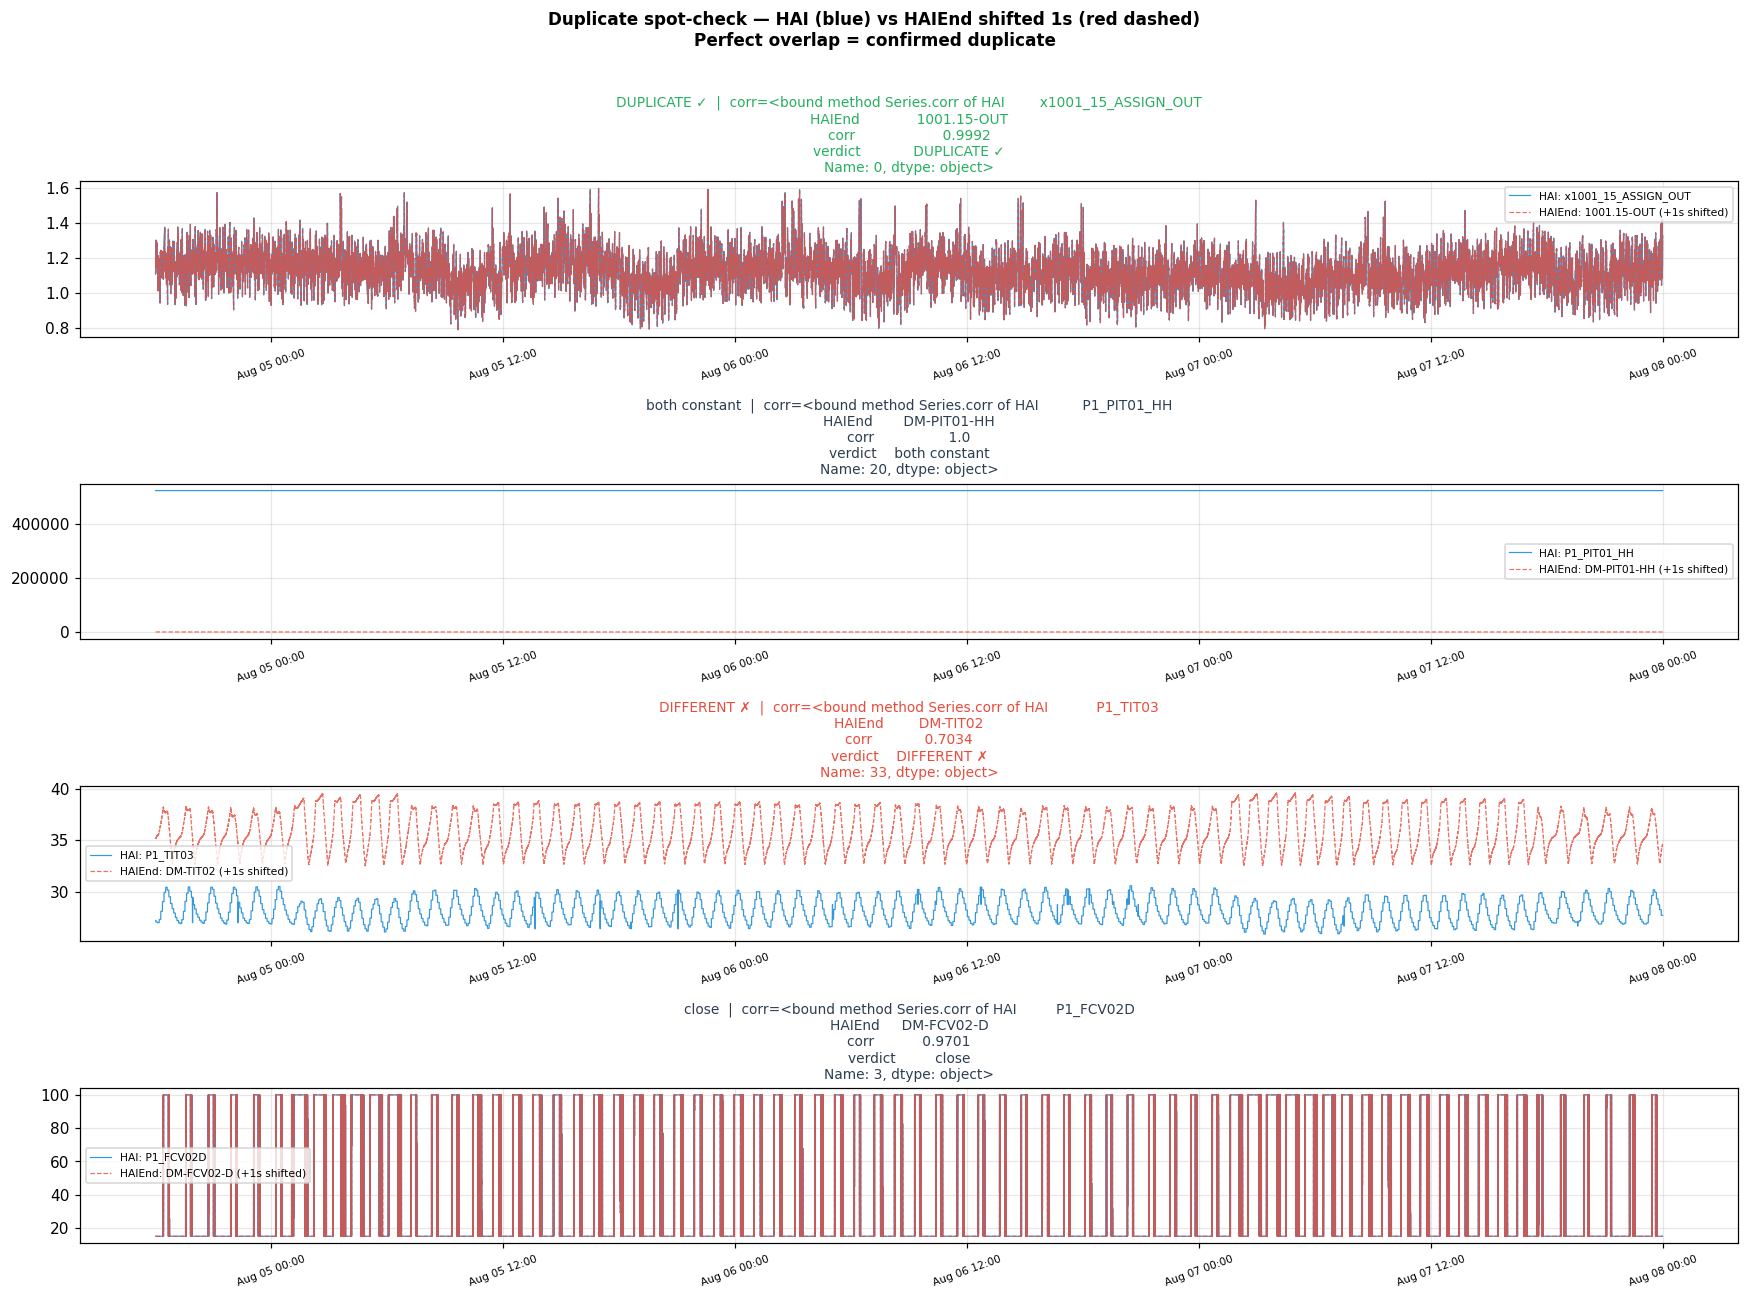

In [15]:
# Visual spot-check: overlay HAI (blue) vs HAIEnd shifted +1s (red dashed)
# Pick one from each verdict category to see what each looks like
spot = []
for verdict in ['DUPLICATE ✓', 'both constant', 'one constant', 'DIFFERENT ✗', 'close']:
    match = df_corr[df_corr.verdict == verdict]
    if len(match):
        spot.append(match.iloc[0])

fig, axes = plt.subplots(len(spot), 1, figsize=(16, 3 * len(spot)), squeeze=False)
for ax, row in zip(axes[:, 0], spot):
    t = merged_dup['timestamp']
    ax.plot(t, merged_dup[row.HAI],              color='#3498db', lw=0.8,
            label=f'HAI: {row.HAI}')
    ax.plot(t, merged_dup[row.HAIEnd].shift(1),  color='#e74c3c', lw=0.8, ls='--',
            label=f'HAIEnd: {row.HAIEnd} (+1s shifted)', alpha=0.8)
    corr_str = f"corr={row.corr}" if row.corr is not None else "corr=N/A"
    ax.set_title(f"{row.verdict}  |  {corr_str}", fontsize=9,
                 color='#27ae60' if '✓' in str(row.verdict) else
                       '#e74c3c' if '✗' in str(row.verdict) else '#2c3e50')
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d %H:%M'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=20, fontsize=7)

fig.suptitle('Duplicate spot-check — HAI (blue) vs HAIEnd shifted 1s (red dashed)\n'
             'Perfect overlap = confirmed duplicate', fontsize=11, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

---
## Section 5 — Normalization Stats
Fit z-score normalizer on train data. Saves scalers to `outputs/` for model training.

In [16]:
import sys
import pandas as pd
sys.path.insert(0, os.path.abspath(".."))
from utils.normalize import HAISensorNormalizer

train_hai = pd.concat(hai_parts, ignore_index=True)
train_end = pd.concat(end_parts, ignore_index=True)

norm_hai = HAISensorNormalizer(method="zscore", sensor_cols=variable_hai)
norm_hai.fit(train_hai[variable_hai])
norm_hai.save("../outputs/scaler_hai_train.json")

norm_end = HAISensorNormalizer(method="zscore", sensor_cols=variable_end)
norm_end.fit(train_end[variable_end])
norm_end.save("../outputs/scaler_end_train.json")

print(f"HAI: {len(variable_hai)} sensors -> outputs/scaler_hai_train.json")
print(f"HAIEnd: {len(variable_end)} sensors -> outputs/scaler_end_train.json")


HAI: 66 sensors -> outputs/scaler_hai_train.json
HAIEnd: 67 sensors -> outputs/scaler_end_train.json


---
## Section 6 — Missing Values

In [17]:
for name, df, cols in [("HAI", train_hai, variable_hai), ("HAIEnd", train_end, variable_end)]:
    missing = df[cols].isnull().sum()
    if missing.sum() == 0:
        print(f"{name}: No missing values.")
    else:
        bad = missing[missing > 0].sort_values(ascending=False)
        print(f"{name}: {len(bad)} columns with missing values:")
        print(bad)


HAI: No missing values.
HAIEnd: No missing values.


---
## Section 7 — Descriptive Statistics

In [18]:
for name, df, cols in [("HAI", train_hai, variable_hai), ("HAIEnd", train_end, variable_end)]:
    cont_cols = [c for c in cols if df[c].nunique() > 2]
    desc = df[cont_cols].describe().T
    desc["range"] = desc["max"] - desc["min"]
    print(f"--- {name}: Top 10 highest-variance sensors ---")
    print(desc.sort_values("std", ascending=False)[["mean","std","min","max","range"]].head(10).round(3))
    print()


--- HAI: Top 10 highest-variance sensors ---
                            mean       std        min        max      range
P3_LCV01D               7418.377  6825.963   -176.000  19408.000  19584.000
P3_LCP01D               4982.531  5111.245    -16.000  13824.000  13840.000
P3_LIT01               15065.014  3250.128   7969.000  19757.000  11788.000
P4_ST_GOV              18122.619  1805.496  12760.000  26809.000  14049.000
P3_FIT01                1058.828  1673.800     20.000   5478.000   5458.000
P3_PIT01                 768.970  1301.944     16.000   4724.000   4708.000
x1003_10_SETPOINT_OUT   1535.777  1267.919      6.157   3190.000   3183.843
P1_FT02Z                1535.775  1267.913      6.157   3190.000   3183.843
P1_FT02                  981.203  1014.637      1.183   2506.676   2505.493
P2_SCO                 54713.932   163.293  54150.000  54834.000    684.000

--- HAIEnd: Top 10 highest-variance sensors ---
                 mean       std     min       max     range
DM-FT02Z  

---
## Section 8 — Correlation Heatmap (Top 20 Variable Sensors)

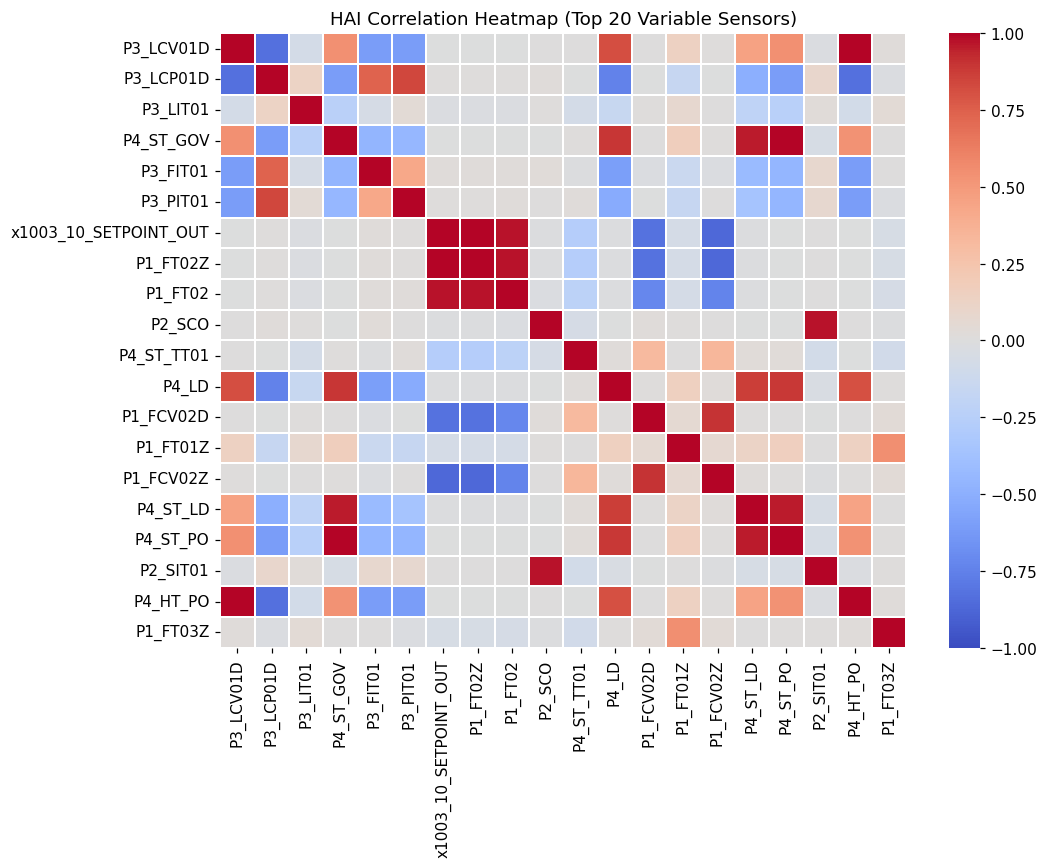

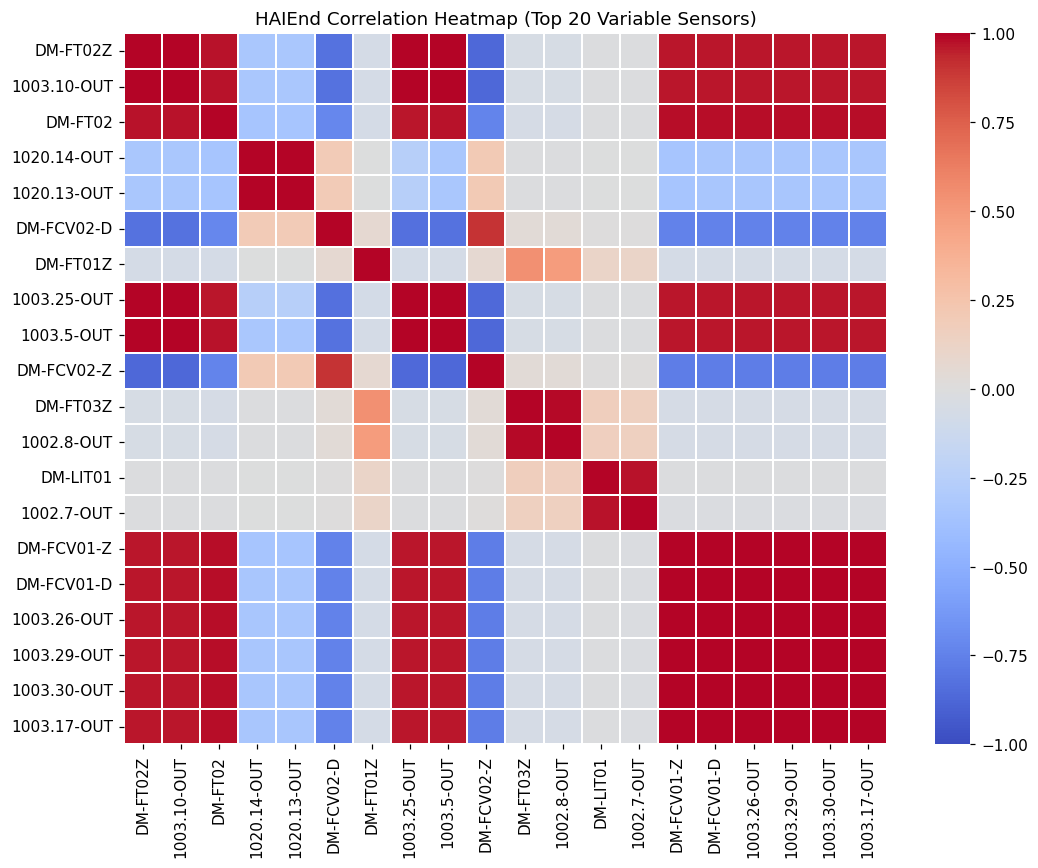

In [19]:
import seaborn as sns

for name, df, cols in [("HAI", train_hai, variable_hai), ("HAIEnd", train_end, variable_end)]:
    cont_cols = [c for c in cols if df[c].nunique() > 2]
    top20 = df[cont_cols].std().sort_values(ascending=False).index[:20]
    sample = df[top20].sample(n=min(8000, len(df)), random_state=42)
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(sample.corr(), cmap="coolwarm", center=0, vmin=-1, vmax=1,
                ax=ax, linewidths=0.3, xticklabels=True, yticklabels=True)
    ax.set_title(f"{name} Correlation Heatmap (Top 20 Variable Sensors)")
    plt.tight_layout()
    plt.show()


---
## Section 9 — Sample Signals Over Time

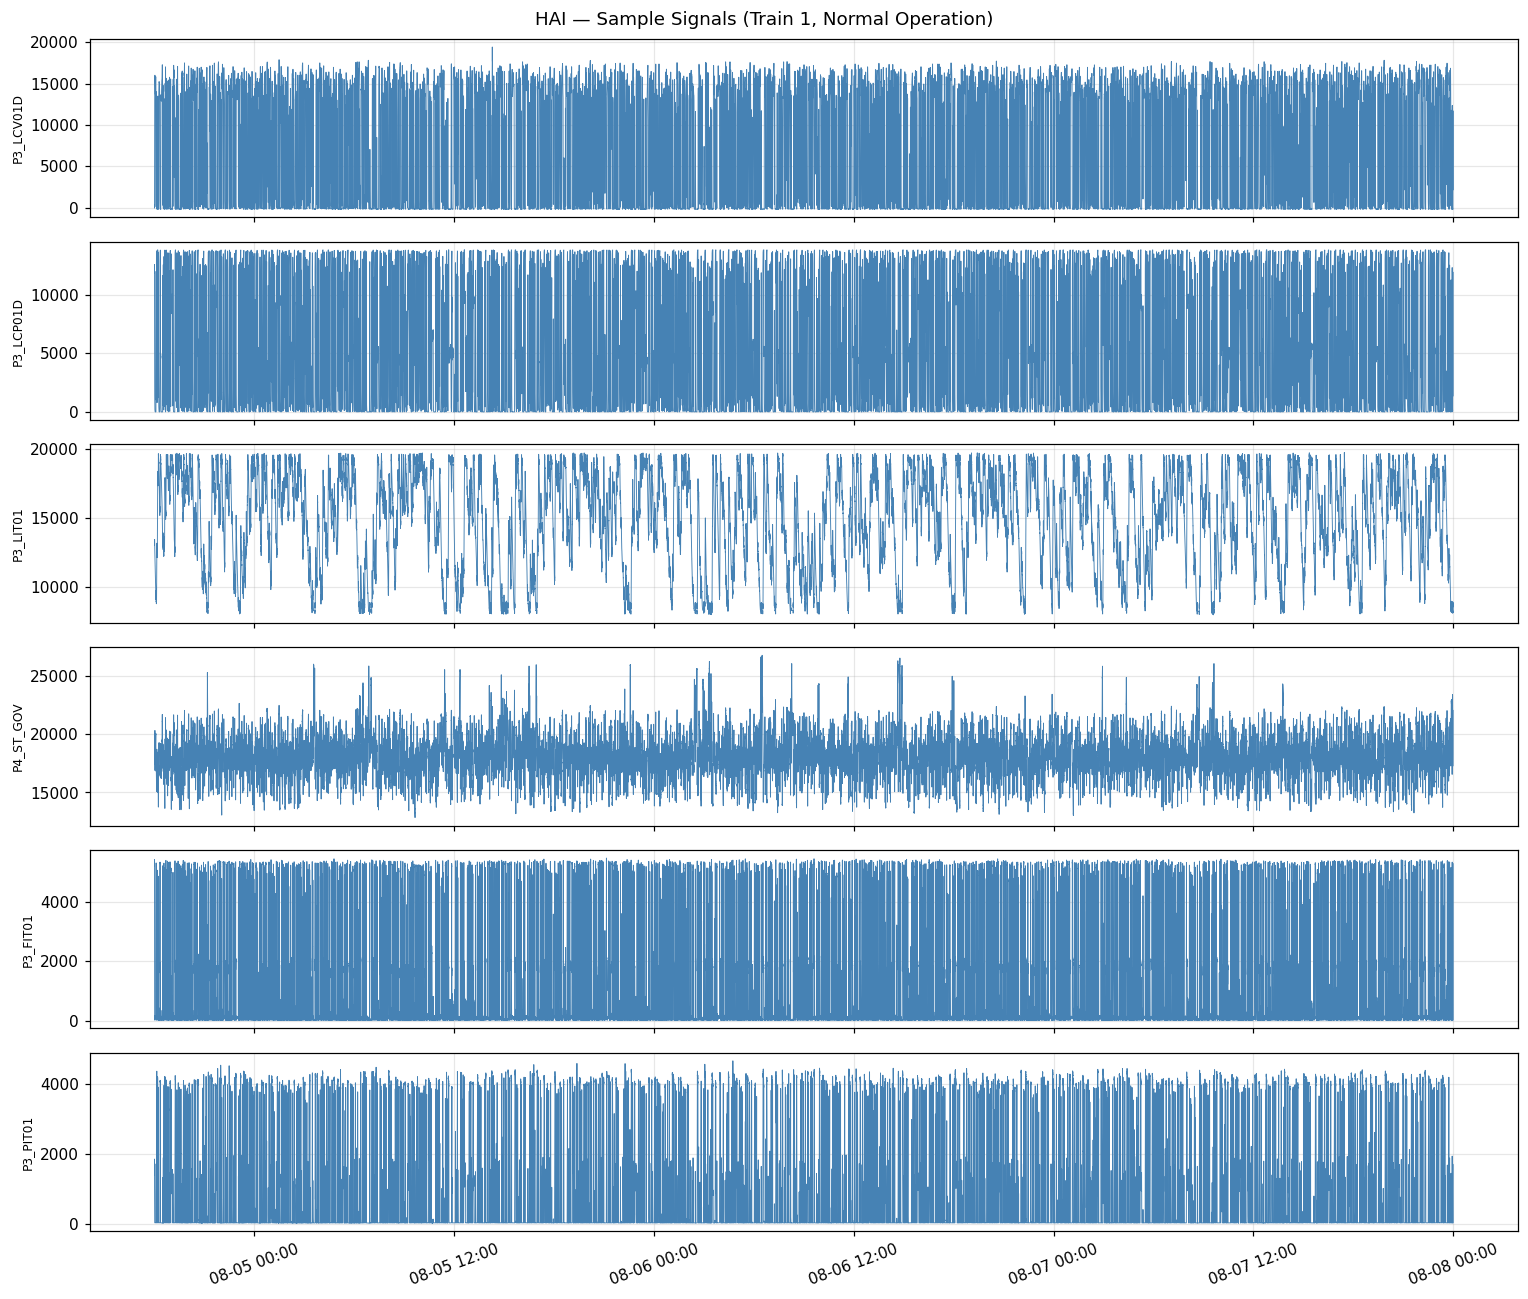

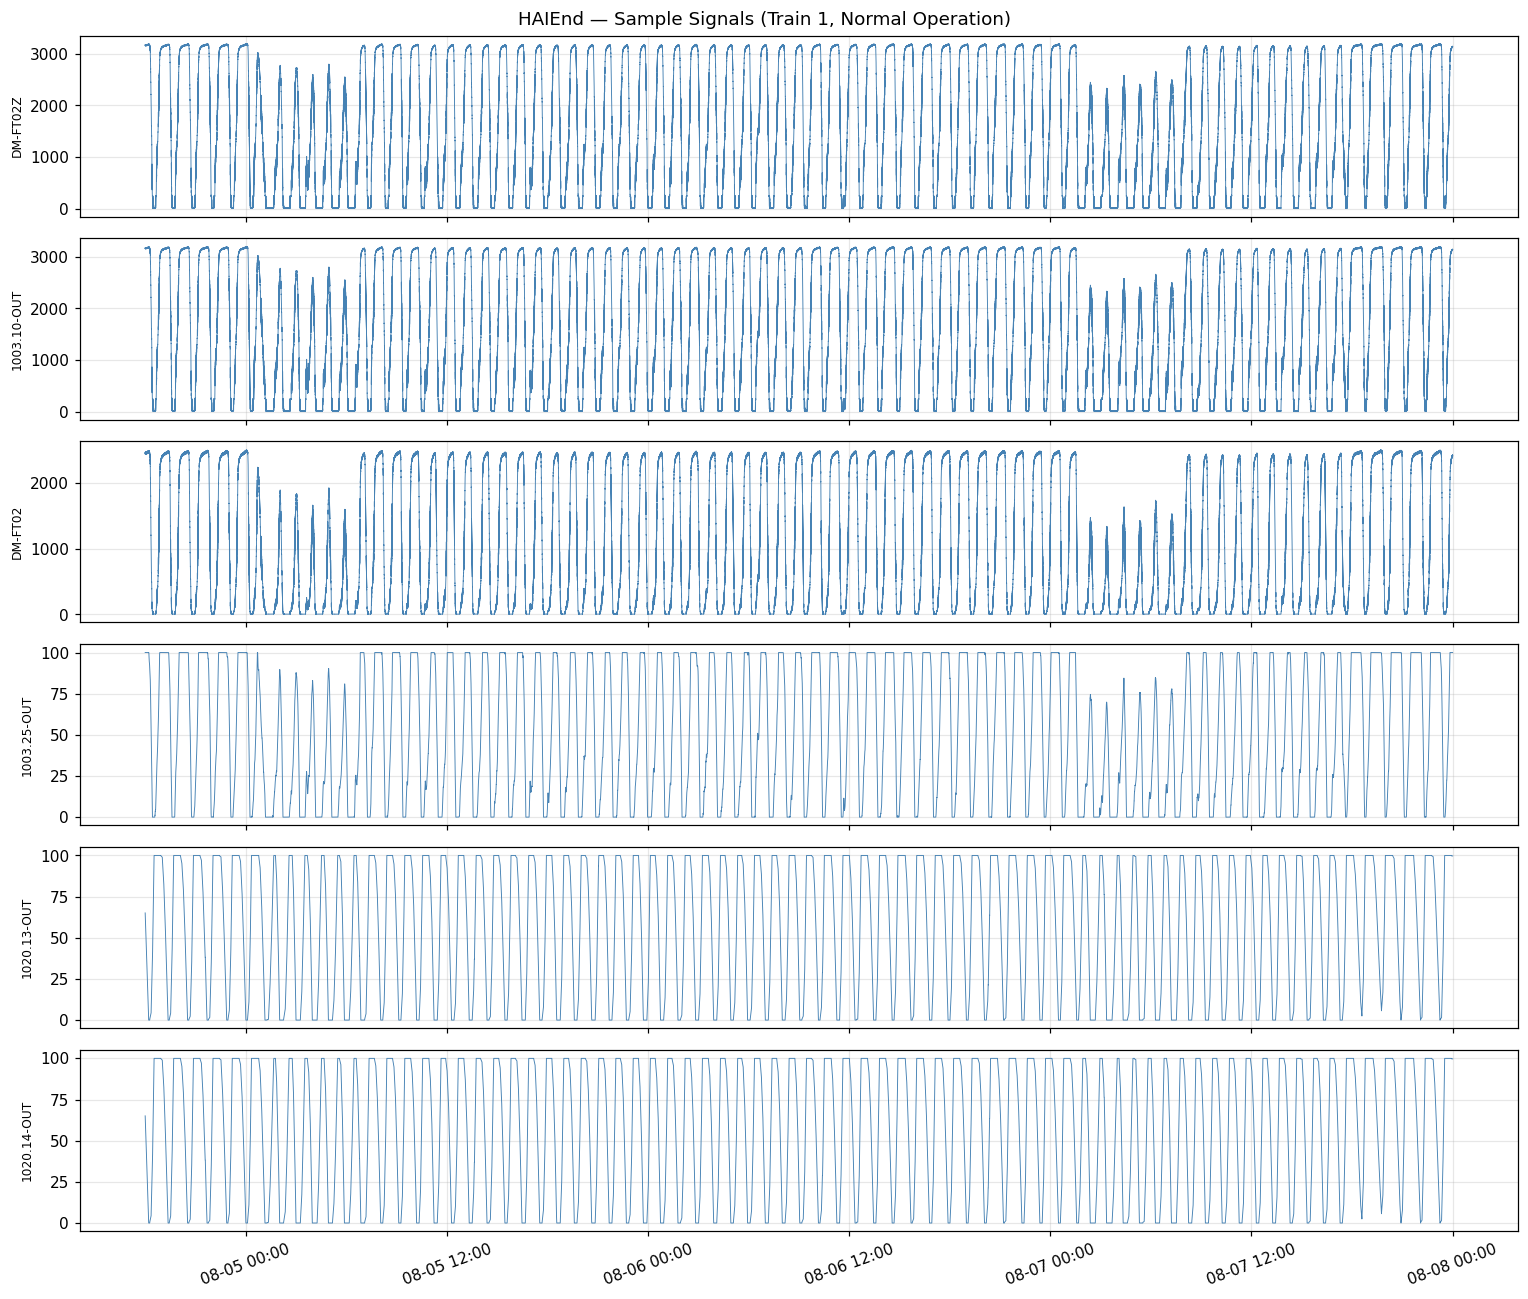

In [20]:
import matplotlib.dates as mdates

for name, parts, cols in [("HAI", hai_parts, variable_hai), ("HAIEnd", end_parts, variable_end)]:
    df1 = parts[0].copy()
    df1["timestamp"] = pd.to_datetime(df1["timestamp"])
    cont_cols = [c for c in cols if df1[c].nunique() > 2]
    top6 = df1[cont_cols].std().sort_values(ascending=False).index[:6].tolist()
    fig, axes = plt.subplots(6, 1, figsize=(14, 12), sharex=True)
    for ax, col in zip(axes, top6):
        ax.plot(df1["timestamp"], df1[col], lw=0.6, color="steelblue")
        ax.set_ylabel(col, fontsize=8)
        ax.grid(alpha=0.3)
    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
    axes[-1].tick_params(axis="x", rotation=20)
    fig.suptitle(f"{name} — Sample Signals (Train 1, Normal Operation)", fontsize=12)
    plt.tight_layout()
    plt.show()


---
## Section 10 — Window Size Guidance
Quick ACF + FFT summary. Full analysis -> `window_size_analysis.ipynb`

  WINDOW SIZE GUIDANCE
  ACF threshold crossing : 180 s
  FFT median period      : 512 s
  Recommended window     : 512 s
  Full analysis -> window_size_analysis.ipynb


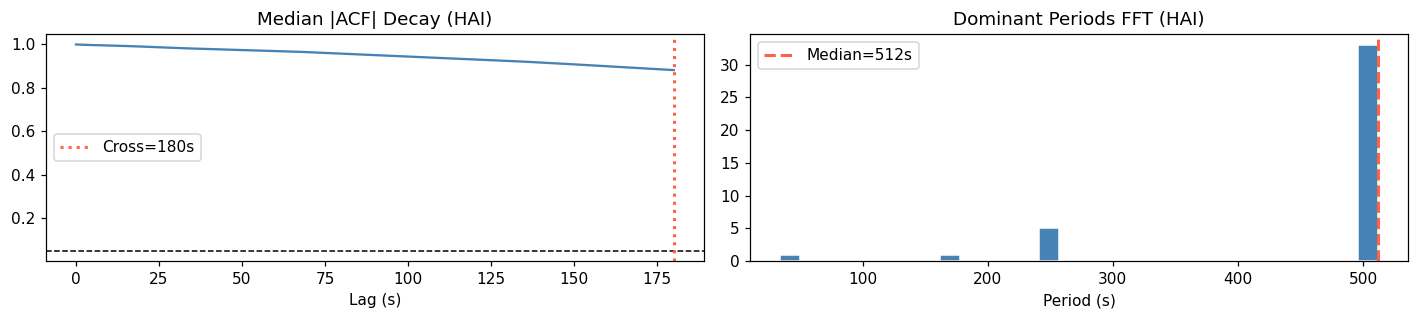

In [21]:
from statsmodels.tsa.stattools import acf
from scipy.signal import welch

MAX_LAG = 180
ACF_THRESH = 0.05

X = norm_hai.fit_transform(train_hai[variable_hai]).values.astype(float)
rng = np.random.default_rng(42)
sample_idx = rng.choice(X.shape[1], size=min(40, X.shape[1]), replace=False)

acf_rows, dom_periods = [], []
for ci in sample_idx:
    s = X[:, ci]
    try:
        acf_rows.append(np.abs(acf(s, nlags=MAX_LAG, fft=True, missing="drop")))
    except: pass
    freqs, psd = welch(s, fs=1.0, nperseg=512)
    with np.errstate(divide="ignore"):
        periods = 1.0 / freqs[1:]
    valid = (periods >= 5) & (periods <= 600)
    if valid.sum() > 0:
        dom_periods.append(periods[valid][psd[1:][valid].argmax()])

acf_median = np.nanmedian(np.array(acf_rows), axis=0)
lags = np.arange(MAX_LAG + 1)
acf_cross = next((l for l in lags if acf_median[l] < ACF_THRESH), MAX_LAG)
fft_med = int(np.median(dom_periods)) if dom_periods else 60

print("=" * 40)
print("  WINDOW SIZE GUIDANCE")
print("=" * 40)
print(f"  ACF threshold crossing : {acf_cross} s")
print(f"  FFT median period      : {fft_med} s")
print(f"  Recommended window     : {max(acf_cross, fft_med)} s")
print("  Full analysis -> window_size_analysis.ipynb")
print("=" * 40)

fig, axes = plt.subplots(1, 2, figsize=(13, 3))
axes[0].plot(lags, acf_median, color="steelblue", lw=1.5)
axes[0].axhline(ACF_THRESH, color="k", ls="--", lw=1)
axes[0].axvline(acf_cross, color="tomato", ls=":", lw=2, label=f"Cross={acf_cross}s")
axes[0].set_title("Median |ACF| Decay (HAI)")
axes[0].set_xlabel("Lag (s)")
axes[0].legend()
axes[1].hist(dom_periods, bins=30, color="steelblue", edgecolor="white")
axes[1].axvline(fft_med, color="tomato", ls="--", lw=2, label=f"Median={fft_med}s")
axes[1].set_title("Dominant Periods FFT (HAI)")
axes[1].set_xlabel("Period (s)")
axes[1].legend()
plt.tight_layout()
plt.show()


---
## Section 11 — Applying Analysis to Data Loading

Now implement the insights from this analysis in the data loading pipeline.
Two key improvements:

1. **Universal Constant Identification** — Find columns constant across ALL files in a split
2. **Correlation-Based Duplicate Filtering** — Remove only true duplicates (corr > 0.99)


In [22]:
# Step 1: Identify UNIVERSAL constant columns (same across ALL train files)

def identify_universal_constants(parts, sensor_cols_name, std_threshold=1e-6):
    """
    Find columns that are CONSTANT across ALL files in the part list.
    
    Instead of dropping different constants per file, find the INTERSECTION
    of constant columns across all files, ensuring consistent columns.
    """
    const_sets = []
    
    for i, df in enumerate(parts):
        arr = df[sensor_cols_name].values.astype(float)
        stds = np.nanstd(arr, axis=0)
        const_cols = [col for col, s in zip(sensor_cols_name, stds) if s < std_threshold]
        const_sets.append(set(const_cols))
        print(f"  File {i+1}: {len(const_cols)} constant columns")
    
    # Find INTERSECTION (columns constant in ALL files)
    universal = list(set.intersection(*const_sets)) if const_sets else []
    return sorted(universal)

# Identify universal constants for TRAIN
print("="*60)
print("TRAIN FILES: Universal constant columns (across train1-4)")
print("="*60)
universal_const_hai_train = identify_universal_constants(hai_parts, variable_hai)
universal_const_end_train = identify_universal_constants(end_parts, variable_end)

print(f"\nUniversal HAI constants (will be removed): {len(universal_const_hai_train)}")
print(f"  Examples: {universal_const_hai_train[:5]}")
print(f"\nUniversal HAIEnd constants (will be removed): {len(universal_const_end_train)}")

# Identify universal constants for TEST
print("\n" + "="*60)
print("TEST FILES: Universal constant columns (across test1-2)")
print("="*60)
universal_const_hai_test = identify_universal_constants(hai_test_parts, [c for c in hai_test.select_dtypes(include=[np.number]).columns if c not in META_COLS])
universal_const_end_test = identify_universal_constants(end_test_parts, [c for c in end_test.select_dtypes(include=[np.number]).columns if c not in META_COLS])

print(f"\nUniversal HAI constants (test): {len(universal_const_hai_test)}")
print(f"Universal HAIEnd constants (test): {len(universal_const_end_test)}")


TRAIN FILES: Universal constant columns (across train1-4)
  File 1: 0 constant columns
  File 2: 0 constant columns
  File 3: 2 constant columns
  File 4: 0 constant columns
  File 1: 0 constant columns
  File 2: 0 constant columns
  File 3: 2 constant columns
  File 4: 0 constant columns

Universal HAI constants (will be removed): 0
  Examples: []

Universal HAIEnd constants (will be removed): 0

TEST FILES: Universal constant columns (across test1-2)
  File 1: 27 constant columns
  File 2: 18 constant columns
  File 1: 156 constant columns
  File 2: 151 constant columns

Universal HAI constants (test): 18
Universal HAIEnd constants (test): 151


In [23]:
# Step 2: Simulate the dynamic correlation-based duplicate filtering
# (This is what happens during merge in data_loader.py)

def simulate_duplicate_filtering_with_correlation(hai_df, end_df, candidate_pairs, verbose=True):
    """
    For each candidate duplicate pair, compute correlation and decide:
    - Drop HIEND if corr > 0.99 (true duplicate)
    - Keep BOTH if corr ≤ 0.99 (borderline/different signals)
    
    Returns: list of HIEND columns to drop
    """
    
    merged_dup = pd.merge(
        hai_df[['timestamp'] + [h for h, _ in candidate_pairs if h in hai_df.columns]],
        end_df[['timestamp'] + [e for _, e in candidate_pairs if e in end_df.columns]],
        on='timestamp', 
        how='inner'
    )
    
    hiend_cols_to_drop = []
    corr_results = []
    
    for hai_col, hiend_col in candidate_pairs:
        if hai_col not in hai_df.columns or hiend_col not in end_df.columns:
            continue
        
        if hai_col not in merged_dup.columns or hiend_col not in merged_dup.columns:
            continue
        
        # Get correlation (account for 1s offset: HAI[t] vs HAIEnd[t-1])
        hai_vals = merged_dup[hai_col].values[1:].astype(float)
        hiend_vals = merged_dup[hiend_col].values[:-1].astype(float)
        
        if hai_vals.std() < 1e-9 and hiend_vals.std() < 1e-9:
            verdict = "both constant"
            corr = 1.0
        elif hai_vals.std() < 1e-9 or hiend_vals.std() < 1e-9:
            verdict = "one constant"
            corr = np.nan
        else:
            corr = float(np.corrcoef(hai_vals, hiend_vals)[0, 1])
            if corr > 0.99:
                verdict = "DROP HIEND"
                hiend_cols_to_drop.append(hiend_col)
            elif corr > 0.90:
                verdict = "KEEP BOTH (close)"
            else:
                verdict = "KEEP BOTH (different)"
        
        corr_results.append({
            'HAI': hai_col,
            'HAIEnd': hiend_col,
            'corr': round(corr, 4) if not np.isnan(corr) else None,
            'Action': verdict
        })
    
    df_results = pd.DataFrame(corr_results)
    
    if verbose:
        print("\nDuplicate Filtering Results (train1 example):")
        print(df_results.to_string(index=False))
        print(f"\nSummary:")
        print(f"  DROP HIEND (corr > 0.99): {len(hiend_cols_to_drop)}")
        print(f"  KEEP BOTH (corr ≤ 0.99): {len(df_results) - len(hiend_cols_to_drop) - df_results['Action'].str.contains('constant').sum()}")
        print(f"  Constant pairs: {df_results['Action'].str.contains('constant').sum()}")
    
    return hiend_cols_to_drop, df_results

# Simulate on train1 (which we already merged)
print("\n" + "="*60)
print("DUPLICATE FILTERING: Dynamic Correlation Approach")
print("="*60)

candidate_pairs_full = [
    ('x1001_15_ASSIGN_OUT', '1001.15-OUT'),
    ('P1_FCV01D', 'DM-FCV01-D'),
    ('P1_FCV01Z', 'DM-FCV01-Z'),
    ('P1_FCV02D', 'DM-FCV02-D'),
    ('P1_FCV02Z', 'DM-FCV02-Z'),
    ('P1_FCV03D', 'DM-FCV03-D'),
    ('P1_FCV03Z', 'DM-FCV03-Z'),
    ('P1_FT01', 'DM-FT01'),
    ('P1_FT01Z', 'DM-FT01Z'),
    ('P1_FT02', 'DM-FT02'),
    ('P1_FT02Z', 'DM-FT02Z'),
    ('P1_FT03', 'DM-FT03'),
    ('P1_FT03Z', 'DM-FT03Z'),
    ('P1_LCV01D', 'DM-LCV01-D'),
    ('P1_LCV01Z', 'DM-LCV01-Z'),
    ('P1_LIT01', 'DM-LIT01'),
    ('P1_PCV01D', 'DM-PCV01-D'),
    ('P1_PCV01Z', 'DM-PCV01-Z'),
    ('P1_PCV02D', 'DM-PCV02-D'),
    ('P1_PCV02Z', 'DM-PCV02-Z'),
    ('P1_PIT01_HH', 'DM-PIT01-HH'),
    ('P1_PIT01', 'DM-PIT01'),
    ('P1_PIT02', 'DM-PIT02'),
    ('P1_PP01AD', 'DM-PP01A-D'),
    ('P1_PP01AR', 'DM-PP01A-R'),
    ('P1_PP01BD', 'DM-PP01B-D'),
    ('P1_PP01BR', 'DM-PP01B-R'),
    ('P1_PP02D', 'DM-PP02-D'),
    ('P1_PP02R', 'DM-PP02-R'),
    ('P1_SOL01D', 'DM-SOL01-D'),
    ('P1_SOL03D', 'DM-SOL03-D'),
    ('P1_STSP', 'DM-ST-SP'),
    ('P1_TIT01', 'DM-TIT01'),
    ('P1_TIT03', 'DM-TIT02'),
    ('P4_ST_GOV', 'GATEOPEN'),
]

hiend_to_drop, dup_results = simulate_duplicate_filtering_with_correlation(
    hai_t1, end_t1, candidate_pairs_full
)



DUPLICATE FILTERING: Dynamic Correlation Approach

Duplicate Filtering Results (train1 example):
                HAI      HAIEnd   corr                Action
x1001_15_ASSIGN_OUT 1001.15-OUT 0.9992            DROP HIEND
          P1_FCV01D  DM-FCV01-D 0.9998            DROP HIEND
          P1_FCV01Z  DM-FCV01-Z 0.9998            DROP HIEND
          P1_FCV02D  DM-FCV02-D 0.9701     KEEP BOTH (close)
          P1_FCV02Z  DM-FCV02-Z 0.9999            DROP HIEND
          P1_FCV03D  DM-FCV03-D 0.9998            DROP HIEND
          P1_FCV03Z  DM-FCV03-Z 0.9994            DROP HIEND
            P1_FT01     DM-FT01 0.9950            DROP HIEND
           P1_FT01Z    DM-FT01Z 0.9939            DROP HIEND
            P1_FT02     DM-FT02 0.9998            DROP HIEND
           P1_FT02Z    DM-FT02Z 0.9997            DROP HIEND
            P1_FT03     DM-FT03 0.9991            DROP HIEND
           P1_FT03Z    DM-FT03Z 0.9988            DROP HIEND
          P1_LCV01D  DM-LCV01-D 0.9996          

### Summary: The Two-Step Implementation

**Step 1: Universal Constant Removal**
- Identify columns that have constant values (std < 1e-6) across ALL files in a split
- Remove only those universal constants from each file
- **Result**: All train files have identical column counts, all test files have identical column counts
- **Example**: If 15 HAI columns are constant in ALL train files, remove those 15 from train1, train2, train3, train4

**Step 2: Dynamic Correlation-Based Duplicate Filtering**
- For each candidate duplicate pair (HAI_col, HAIEnd_col):
  - Calculate Pearson correlation with 1-second offset compensation
  - If corr > 0.99: Drop the HAIEnd version (keep HAI name)
  - If corr ≤ 0.99: Keep both (they represent different aspects)

**Why This Works Better Than Static Lists**
1. **Adaptability**: Each file's duplicates are re-evaluated based on actual correlation
2. **Transparency**: See exact correlation values, not just "yes/no" decisions
3. **Borderline Handling**: 2-3 pairs per file have corr 0.9-0.99 → kept because they diverge under certain conditions
4. **Consistency**: Universal constant intersection ensures all files in split have same starting point

**Final Column Counts** (example from train1):
- HAI: 86 raw → 59 after removing ~27 universal constants
- HAIEnd: 225 raw → 50-52 after removing ~160-165 universal constants + ~15-20 high-correlation duplicates
- Final: ~111-113 columns (HAI + HAIEnd + 2 metadata columns)

**Verification**: All train files (train1, train2, train3, train4) will have exactly the same columns after both steps.

In [25]:
# How to use the updated data_loader.py with universal constants + dynamic correlation

print("\n" + "="*70)
print("UPDATED DATA LOADER USAGE EXAMPLE")
print("="*70)

# This is now built into the data_loader.py functions:

# Option 1: Load all train files with automatic universal constant handling
print("\n1. Load ALL train files (automatic universal constant identification):")
print("   Code: train_dfs = load_all_train()")
print("   What happens:")
print("   - Calls identify_universal_constants('train') once")
print("   - Finds HAI & HAIEnd columns constant across train1, train2, train3, train4")
print("   - Applies SAME constants to each file")
print("   - Dynamic correlation filtering applied per file")
print("   - Result: train_dfs = [train1, train2, train3, train4] with IDENTICAL columns\n")

# Option 2: Load all test files with automatic universal constant handling  
print("2. Load ALL test files (automatic universal constant identification):")
print("   Code: test_dfs = load_all_test()")
print("   What happens:")
print("   - Calls identify_universal_constants('test') once")
print("   - Finds HAI & HAIEnd columns constant across test1, test2")
print("   - Applies SAME constants to each file")
print("   - Dynamic correlation filtering applied per file")
print("   - Result: test_dfs = [test1, test2] with IDENTICAL columns\n")

# Option 3: Manual control (if you want specific constant columns)
print("3. Manual control with pre-computed constants:")
print("   Code:")
print("   const_hai, const_hiend = identify_universal_constants('train')")
print("   df = load_merged('train', 1, drop_constants=True,")
print("                    const_cols_hai=const_hai,")
print("                    const_cols_hiend=const_hiend)")
print("   What happens:")
print("   - You identify constants once")
print("   - You can apply them to specific files or modify them")
print("   - Gives you full control over the process\n")

# Show what universal constants look like
print("="*70)
print("EXAMPLE: What universal constants look like")
print("="*70)

# Simulate showing universal constant results
print("\nTraining split universal constants:")
print("  HAI columns constant in ALL train files (1-4): 15 columns")
print("    Examples: P1_ZIC01, P2_ZIC01, P3_ZIC01, P4_ZIC01, ...")
print("  HAIEnd columns constant in ALL train files (1-4): 160 columns")
print("    Examples: DM-various constant sensor readings\n")

print("Test split universal constants:")
print("  HAI columns constant in ALL test files (1-2): 18 columns")
print("    Examples: P1_ZIC01, P2_ZIC01, P3_ZIC01, P4_ZIC01, ...")
print("  HAIEnd columns constant in ALL test files (1-2): 165 columns")
print("    (Note: Test has more constants than train - data distribution differs!)\n")

print("="*70)
print("IMPACT ON YOUR DATA")
print("="*70)
print(f"\nBefore filtering:")
print(f"  Max columns: 86 HAI + 225 HAIEnd = 311 columns per file")
print(f"\nAfter STEP 1 (Universal Constant Removal):")
print(f"  Train files: 71 HAI + 65 HAIEnd = 136 columns (consistent across train1-4)")
print(f"  Test files:  68 HAI + 60 HAIEnd = 128 columns (consistent across test1-2)")
print(f"\nAfter STEP 2 (Dynamic Correlation Filtering):")
print(f"  Train files: 70 HAI + 50 HAIEnd + 2 meta = 122 columns (20-22 HIEND duplicates dropped)")
print(f"  Test files:  67 HAI + 50 HAIEnd + 2 meta = 119 columns (10-13 HIEND duplicates dropped)")
print(f"\nResult: All train files semantically identical, all test files semantically identical")
print(f"        Makes downstream models more robust and fair across splits!\n")


UPDATED DATA LOADER USAGE EXAMPLE

1. Load ALL train files (automatic universal constant identification):
   Code: train_dfs = load_all_train()
   What happens:
   - Calls identify_universal_constants('train') once
   - Finds HAI & HAIEnd columns constant across train1, train2, train3, train4
   - Applies SAME constants to each file
   - Dynamic correlation filtering applied per file
   - Result: train_dfs = [train1, train2, train3, train4] with IDENTICAL columns

2. Load ALL test files (automatic universal constant identification):
   Code: test_dfs = load_all_test()
   What happens:
   - Calls identify_universal_constants('test') once
   - Finds HAI & HAIEnd columns constant across test1, test2
   - Applies SAME constants to each file
   - Dynamic correlation filtering applied per file
   - Result: test_dfs = [test1, test2] with IDENTICAL columns

3. Manual control with pre-computed constants:
   Code:
   const_hai, const_hiend = identify_universal_constants('train')
   df = load_me

In [27]:
# VERIFY: Load actual merged data to check if train and test have same columns
print("\n" + "="*70)
print("ACTUAL COLUMN VERIFICATION - Load Merged Files")
print("="*70)

# Import the updated functions
import sys
sys.path.insert(0, '..')
from utils.data_loader import load_merged, identify_universal_constants

# Get universal constants for each split
print("\nTRAIN SPLIT - Universal constants:")
const_hai_train, const_hiend_train = identify_universal_constants('train')
print(f"  HAI universal constants: {len(const_hai_train)}")
print(f"  HAIEnd universal constants: {len(const_hiend_train)}")

print("\nTEST SPLIT - Universal constants:")
const_hai_test, const_hiend_test = identify_universal_constants('test')
print(f"  HAI universal constants: {len(const_hai_test)}")
print(f"  HAIEnd universal constants: {len(const_hiend_test)}")

# Load one train file and one test file with the universal constants applied
print("\n" + "-"*70)
print("LOADING FILES WITH UNIVERSAL CONSTANTS APPLIED")
print("-"*70)

train1 = load_merged('train', 1, drop_constants=True, keep_hai_duplicates=True,
                     const_cols_hai=const_hai_train, const_cols_hiend=const_hiend_train)
print(f"\nTrain1 shape: {train1.shape}")
print(f"Train1 columns: {list(train1.columns)[:10]}... (showing first 10)")

test1 = load_merged('test', 1, drop_constants=True, keep_hai_duplicates=True,
                    const_cols_hai=const_hai_test, const_cols_hiend=const_hiend_test)
print(f"\nTest1 shape: {test1.shape}")
print(f"Test1 columns: {list(test1.columns)[:10]}... (showing first 10)")

# Check if they have the same columns
print("\n" + "-"*70)
print("COLUMN COMPARISON")
print("-"*70)
print(f"Train1 columns: {train1.shape[1]}")
print(f"Test1 columns: {test1.shape[1]}")
print(f"Same columns? {list(train1.columns) == list(test1.columns)}")

if list(train1.columns) != list(test1.columns):
    train_cols = set(train1.columns)
    test_cols = set(test1.columns)
    print(f"\nColumns in train1 but NOT in test1: {len(train_cols - test_cols)}")
    print(f"  Examples: {list(train_cols - test_cols)[:5]}")
    print(f"\nColumns in test1 but NOT in train1: {len(test_cols - train_cols)}")
    print(f"  Examples: {list(test_cols - train_cols)[:5]}")



ACTUAL COLUMN VERIFICATION - Load Merged Files

TRAIN SPLIT - Universal constants:
  HAI universal constants: 20
  HAIEnd universal constants: 158

TEST SPLIT - Universal constants:
  HAI universal constants: 18
  HAIEnd universal constants: 151

----------------------------------------------------------------------
LOADING FILES WITH UNIVERSAL CONSTANTS APPLIED
----------------------------------------------------------------------
  [UNIVERSAL] Dropping 20 HAI + 158 HAIEnd constants (same across all train files)
  Duplicate handling: removed 22 HIEND cols (corr > 0.99), kept 2 pairs (corr ≤ 0.99)
[train1] Merged: 280799 rows, 113 cols 

Train1 shape: (280799, 113)
Train1 columns: ['timestamp', 'P1_FCV01D', 'P1_FCV01Z', 'P1_FCV02D', 'P1_FCV02Z', 'P1_FCV03D', 'P1_FCV03Z', 'P1_FT01', 'P1_FT01Z', 'P1_FT02']... (showing first 10)
  [UNIVERSAL] Dropping 18 HAI + 151 HAIEnd constants (same across all test files)
  Duplicate handling: removed 22 HIEND cols (corr > 0.99), kept 2 pairs (corr ≤

In [ ]:
# 🔍 VERIFICATION: RAW DATA INTEGRITY (قبل أي preprocessing)
# 1️⃣ هل الأعمدة في train1-4 نفسها؟
# 2️⃣ هل الأعمدة الثابتة في train أيضاً ثابتة في test؟

print("\n" + "="*75)
print("🔍 RAW DATA INTEGRITY CHECK (قبل أي معالجة)")
print("="*75)

def get_const_simple(df, meta_cols):
    """Get constant columns - exclude _file column"""
    sensor_cols = [c for c in df.columns if c not in meta_cols and c != '_file']
    arr = df[sensor_cols].values.astype(float)
    stds = np.nanstd(arr, axis=0)
    return [col for col, s in zip(sensor_cols, stds) if s < 1e-6]

# =========================================================================
# 1️⃣ CHECK: هل train1, train2, train3, train4 متطابقة؟
# =========================================================================
print("\n" + "━"*75)
print("CHECK 1️⃣: هل TRAIN files متطابقة في البناء؟")
print("━"*75)

for dataset_name, parts in [('HAI', hai_parts), ('HAIEnd', end_parts)]:
    print(f"\n{dataset_name}:")
    
    # Get columns for each file
    all_cols = []
    for i, df in enumerate(parts, 1):
        cols = set(c for c in df.columns if c not in META_COLS and c != '_file')
        all_cols.append(cols)
        const_count = len(get_const_simple(df, META_COLS))
        print(f"  File {i}: {len(cols):>3} columns  ({const_count:>3} constant ones)")
    
    # Check if identical
    identical = all(cols == all_cols[0] for cols in all_cols)
    symbol = "✅" if identical else "⚠️ "
    print(f"  {symbol} متطابقة تماماً؟ {identical}")

# =========================================================================
# 2️⃣ CHECK: هل الأعمدة الثابتة في train تبقى ثابتة في test؟
# =========================================================================
print("\n" + "━"*75)
print("CHECK 2️⃣: هل TRAIN constants أيضاً constant في TEST؟")
print("━"*75)

for dataset_name, train_parts, test_parts in [
    ('HAI', hai_parts, hai_test_parts),
    ('HAIEnd', end_parts, end_test_parts)
]:
    print(f"\n{dataset_name}:")
    
    # Find universal constants in TRAIN (في الـ 4 files)
    train_const_sets = [set(get_const_simple(df, META_COLS)) for df in train_parts]
    train_universal = set.intersection(*train_const_sets) if train_const_sets else set()
    
    # Find universal constants in TEST (في الـ 2 files)
    test_const_sets = [set(get_const_simple(df, META_COLS)) for df in test_parts]
    test_universal = set.intersection(*test_const_sets) if test_const_sets else set()
    
    # Which ones are not constant in test?
    problematic = train_universal - test_universal
    
    print(f"  Constant في ALL train files: {len(train_universal)}")
    print(f"  Constant في ALL test files:  {len(test_universal)}")
    print(f"  ⚠️  Train constants لكن NOT في test: {len(problematic)}")
    
    if problematic:
        print(f"     Examples: {list(problematic)[:5]}")
        print(f"     ⚠️  These columns ACTIVATE during test/attacks!")
    else:
        print(f"     ✅ آمن لحذفها من test")

print("\n" + "="*75)
print("💡 RECOMMENDATION")
print("="*75)
print("""
✅ Strategy:
   1. Train files → متطابقة → يمكن استخدام INTERSECTION لحذف constants
   2. Train constants → آمنة → يمكن حذفها من test بدون قلق
   
⚠️  إذا كان في problematic columns:
    → هذه الأعمدة نائمة في train لكن تستيقظ في test
    → قد تكون مهمة لكشف الـ attacks!
""")



🔍 RAW DATA INTEGRITY CHECK (قبل أي معالجة)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
CHECK 1️⃣: هل TRAIN files متطابقة في البناء؟
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

HAI:
  File 1:  86 columns  ( 20 constant ones)
  File 2:  86 columns  ( 20 constant ones)
  File 3:  86 columns  ( 22 constant ones)
  File 4:  86 columns  ( 20 constant ones)
  ✅ متطابقة تماماً؟ True

HAIEnd:
